# Activity recognition chain

This study rebuilds the case study of a tutorial paper on activity recognition with body worn motion sensors. It uses the ActRecTut gesture recordings, where each person wears motion sensors on one arm.

You will follow the recognition chain step by step: cut the signal into windows, compute features, train a classifier and score it with precision and recall. Then you will see how window size, features, sensor placement, sensor type, classifier and feature selection change the scores, and how our scores compare with the values the paper prints.

In [1]:
# Folders, random seed and number of worker processes
dataRoot = "/app/data"
resultsRoot = "/app/results"
randomSeed = 42
nJobs = 4

In [2]:
# Download the dataset, only when it is not on disk yet
from dataFetch.fetchData import dataFetcher

dataFetcher(dataRoot, nJobs=nJobs).fetchAll(["actRecTut"])

[ DATA FETCH : ALREADY PRESENT ] : actRecTut


## Set up the study

This step creates the study object, which loads both recordings, and imports the helpers used below. It then fixes the random seeds, the thread limits and the plot style, so that every run gives the same files.

In [3]:
from IPython.display import Image, display

from activityRecognitionChain.chainStudy import chainStudy
from common.csvWriters import readCsv

study = chainStudy(dataRoot, resultsRoot, randomSeed=randomSeed, nJobs=nJobs)
study.prepareRun()

## Part 1: The data

### Data inventory

Each recording is one long stream of sensor values with a label for every frame. This step lists, for each person and class, how many segments there are and how long they last. It also checks that every repetition block holds each gesture exactly once.

In [4]:
study.writeDataInventory()
display(readCsv(study.resultsDirectory / "dataInventory.csv").head(10))

,subject,classLabel,className,segments,frames,seconds,minSegmentSeconds,medianSegmentSeconds,maxSegmentSeconds,shareOfSegmentsInPaperRange
0,1,1,NULL,287,23310,728.4375,0.3125,0.93750,198.03125,0.236934
1,1,2,Open window,26,2826,88.3125,2.6875,3.31250,5.87500,1.000000
2,1,3,Drink,26,3894,121.6875,4.0625,4.68750,5.37500,1.000000
3,1,4,Water plant,26,3734,116.6875,3.8125,4.43750,5.06250,1.000000
4,1,5,Close window,26,3368,105.2500,3.3125,4.00000,4.93750,1.000000
5,1,6,Cut,26,4548,142.1250,3.7500,5.59375,7.37500,1.000000
6,1,7,Chop,26,4504,140.7500,4.4375,5.40625,7.06250,1.000000
7,1,8,Stir,26,4612,144.1250,4.8125,5.40625,7.18750,1.000000
8,1,9,Book,26,6010,187.8125,6.1250,7.25000,8.43750,0.923077
9,1,10,Forehand,26,2030,63.4375,1.8750,2.43750,3.37500,0.923077


### Filled frames

Some frames of the published data hold values that were filled in after the recording. This step finds the runs of such frames for each sensor. It also checks whether the filled values equal the mean of the frame's class. The main results use the data as published.

In [5]:
study.inventoryFills()
display(readCsv(study.resultsDirectory / "dataFills.csv").head(10))

,subject,imu,placement,runStart,runEnd,frames,labelCounts,equalsClassMean
0,1,1,hand,62479,62480,1,1:1,False
1,1,2,lowerArm,4379,4404,25,4:25,True
2,1,2,lowerArm,11595,11603,8,4:8,True
3,1,2,lowerArm,15620,15621,1,4:1,True
4,1,2,lowerArm,62479,62480,1,1:1,False
5,2,1,hand,0,251,251,1:251,True
6,2,1,hand,70777,70778,1,1:1,True
7,2,2,lowerArm,0,214,214,1:214,True
8,2,2,lowerArm,512,569,57,1:57,True
9,2,2,lowerArm,576,671,95,1:95,True


## Part 2: The sections of the paper

The figure of each section is drawn at the end of the notebook, together with the paper values it is compared with.

### Section 5.1: The basic chain

The basic chain cuts the signal into windows and computes the mean and variance of every channel. A nearest neighbour rule labels each window. It runs with the hand accelerometer alone and with all sensors. It is scored in a person dependent way, leaving one repetition out inside each person, and in a person independent way, training on one person while testing on the other.

In [6]:
basicTable = study.runBasicChain()
display(readCsv(study.resultsDirectory / "section51BasicChain.csv").head(10))

[ CHAIN : 5.1 handAccelerometer.kNearestNeighbour.paperStep ] : done


[ CHAIN : 5.1 handAccelerometer.nearestClassCentroid.paperStep ] : done


[ CHAIN : 5.1 handAccelerometer.toolboxNearestNeighbours.paperStep ] : done


[ CHAIN : 5.1 allSensors.kNearestNeighbour.paperStep ] : done


[ CHAIN : 5.1 allSensors.nearestClassCentroid.paperStep ] : done


...

[ CHAIN : 5.1 handAccelerometer.kNearestNeighbour.toolboxStep ] : done


[ CHAIN : 5.1 handAccelerometer.nearestClassCentroid.toolboxStep ] : done


[ CHAIN : 5.1 allSensors.kNearestNeighbour.toolboxStep ] : done


[ CHAIN : 5.1 allSensors.nearestClassCentroid.toolboxStep ] : done


,section,configuration,sensorSet,stepVariant,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,...,eventRecallNonNull,detectedGestureSegmentShare,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2
0,5.1,handAccelerometer.kNearestNeighbour.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.723407,0.989510,0.725473,0.704010,0.724918,0.701185,0.751671,0.713290,0.756531,0.708907
1,5.1,handAccelerometer.kNearestNeighbour.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.296714,0.624126,0.376815,0.297038,0.354843,0.276454,0.400010,0.357188,0.373405,0.317211
2,5.1,handAccelerometer.nearestClassCentroid.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,nearestClassCentroid,1.0,1.0,personDependent,...,0.550735,0.928322,0.735594,0.580244,0.741984,0.556010,0.605442,0.547814,0.600532,0.528776
3,5.1,handAccelerometer.nearestClassCentroid.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,nearestClassCentroid,1.0,1.0,personIndependent,...,0.373941,0.674825,0.491400,0.388069,0.469884,0.361969,0.370635,0.376206,0.331394,0.375516
4,5.1,handAccelerometer.toolboxNearestNeighbours.pap...,handAccelerometer,paperStep,acc_1,VerySimple,toolboxNearestNeighbours,1.0,1.0,personDependent,...,0.718284,0.986014,0.771968,0.716547,0.776353,0.705012,0.779972,0.708615,0.790541,0.696125
5,5.1,handAccelerometer.toolboxNearestNeighbours.pap...,handAccelerometer,paperStep,acc_1,VerySimple,toolboxNearestNeighbours,1.0,1.0,personIndependent,...,0.326640,0.606643,0.421723,0.335740,0.404333,0.297446,0.396655,0.384372,0.368207,0.349488
6,5.1,allSensors.kNearestNeighbour.paperStep,allSensors,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.882380,0.996503,0.844549,0.857725,0.848979,0.868265,0.841584,0.838225,0.849537,0.844141
7,5.1,allSensors.kNearestNeighbour.paperStep,allSensors,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.506648,0.868881,0.597402,0.483996,0.593194,0.453326,0.561673,0.554606,0.538646,0.550027
8,5.1,allSensors.nearestClassCentroid.paperStep,allSensors,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,nearestClassCentroid,1.0,1.0,personDependent,...,0.602026,0.963287,0.752960,0.598972,0.763267,0.573242,0.736911,0.628689,0.742381,0.613867
9,5.1,allSensors.nearestClassCentroid.paperStep,allSensors,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,nearestClassCentroid,1.0,1.0,personIndependent,...,0.475179,0.868881,0.577167,0.443637,0.558752,0.422710,0.531149,0.514418,0.504163,0.515169


### Section 5.2: Feature types

This step keeps the nearest neighbour rule and changes the features. Raw uses every frame as its own instance. Raw window joins the frames of each window. The other sets use the mean and variance, the crossing rates, the spectrum features, or all of them. The scores show which features help.

In [7]:
featureTable = study.compareFeatureTypes()
display(readCsv(study.resultsDirectory / "section52FeatureTypes.csv").head(10))

[ CHAIN : 5.2 handAccelerometer.Raw ] : done


[ CHAIN : 5.2 handAccelerometer.RawWindow ] : done


[ CHAIN : 5.2 handAccelerometer.VerySimple ] : done


[ CHAIN : 5.2 handAccelerometer.Simple ] : done


[ CHAIN : 5.2 handAccelerometer.FFT ] : done


...

[ CHAIN : 5.2 allSensors.VerySimple ] : done


[ CHAIN : 5.2 allSensors.Simple ] : done


[ CHAIN : 5.2 allSensors.FFT ] : done


[ CHAIN : 5.2 allSensors.All ] : done


,section,configuration,sensorSet,featureSet,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,...,eventRecallNonNull,detectedGestureSegmentShare,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2
0,5.2,handAccelerometer.Raw,handAccelerometer,Raw,acc_1,Raw,kNearestNeighbour,0.03125,0.03125,personDependent,...,0.318020,1.000000,0.352237,0.344754,0.331508,0.314127,0.357223,0.352211,0.339143,0.321914
1,5.2,handAccelerometer.Raw,handAccelerometer,Raw,acc_1,Raw,kNearestNeighbour,0.03125,0.03125,personIndependent,...,0.170596,1.000000,0.199561,0.196249,0.166404,0.159650,0.215240,0.207675,0.177393,0.181543
2,5.2,handAccelerometer.RawWindow,handAccelerometer,RawWindow,acc_1,Raw,kNearestNeighbour,1.00000,1.00000,personDependent,...,0.741391,0.986014,0.783911,0.755817,0.789944,0.758103,0.767405,0.690601,0.782839,0.681610
3,5.2,handAccelerometer.RawWindow,handAccelerometer,RawWindow,acc_1,Raw,kNearestNeighbour,1.00000,1.00000,personIndependent,...,0.355316,0.727273,0.600166,0.433378,0.602064,0.393937,0.497992,0.355584,0.486822,0.310186
4,5.2,handAccelerometer.VerySimple,handAccelerometer,VerySimple,acc_1,VerySimple,kNearestNeighbour,1.00000,1.00000,personDependent,...,0.723407,0.989510,0.725473,0.704010,0.724918,0.701185,0.751671,0.713290,0.756531,0.708907
5,5.2,handAccelerometer.VerySimple,handAccelerometer,VerySimple,acc_1,VerySimple,kNearestNeighbour,1.00000,1.00000,personIndependent,...,0.296714,0.624126,0.376815,0.297038,0.354843,0.276454,0.400010,0.357188,0.373405,0.317211
6,5.2,handAccelerometer.Simple,handAccelerometer,Simple,acc_1,Simple,kNearestNeighbour,1.00000,1.00000,personDependent,...,0.683024,0.980769,0.685166,0.667779,0.685035,0.667152,0.704894,0.670561,0.708065,0.665908
7,5.2,handAccelerometer.Simple,handAccelerometer,Simple,acc_1,Simple,kNearestNeighbour,1.00000,1.00000,personIndependent,...,0.355834,0.669580,0.379696,0.361570,0.355482,0.331954,0.384425,0.402659,0.354066,0.372115
8,5.2,handAccelerometer.FFT,handAccelerometer,FFT,acc_1,FFT,kNearestNeighbour,1.00000,1.00000,personDependent,...,0.414977,0.819930,0.467307,0.446503,0.461548,0.440096,0.433258,0.399594,0.429317,0.383084
9,5.2,handAccelerometer.FFT,handAccelerometer,FFT,acc_1,FFT,kNearestNeighbour,1.00000,1.00000,personIndependent,...,0.246676,0.604895,0.319932,0.269922,0.302563,0.243858,0.267062,0.271345,0.239031,0.249460


### Section 5.3: Window size

This step changes the window length and measures the scores for each length. It uses the step rule of the paper and the fixed step of the original toolbox. Short windows give noisy features. Long windows mix neighbouring gestures.

In [8]:
windowTable = study.sweepWindowSizes()
display(readCsv(study.resultsDirectory / "section53WindowSizes.csv").head(10))

[ CHAIN : 5.3 window0.1.paperStep ] : done


[ CHAIN : 5.3 window0.25.paperStep ] : done


[ CHAIN : 5.3 window0.5.paperStep ] : done


[ CHAIN : 5.3 window1.0.paperStep ] : done


[ CHAIN : 5.3 window2.0.paperStep ] : done


...

[ CHAIN : 5.3 window5.0.toolboxStep ] : done


[ CHAIN : 5.3 window6.0.toolboxStep ] : done


[ CHAIN : 5.3 window7.0.toolboxStep ] : done


[ CHAIN : 5.3 window8.0.toolboxStep ] : done


,section,configuration,stepVariant,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,variant,...,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2,actualWindowSeconds,actualStepSeconds
0,5.3,window0.1.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,0.10,0.10,personDependent,NaN,...,0.777061,0.791042,0.780817,0.796350,0.784274,0.784336,0.787511,0.783536,0.09375,0.09375
1,5.3,window0.1.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,0.10,0.10,personIndependent,NaN,...,0.452142,0.381543,0.441313,0.356016,0.436862,0.424252,0.408522,0.402710,0.09375,0.09375
2,5.3,window0.25.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,0.25,0.25,personDependent,NaN,...,0.806065,0.815825,0.810387,0.820677,0.807117,0.809459,0.811219,0.810233,0.25000,0.25000
3,5.3,window0.25.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,0.25,0.25,personIndependent,NaN,...,0.509281,0.405841,0.501882,0.372208,0.498430,0.475812,0.474552,0.457124,0.25000,0.25000
4,5.3,window0.5.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,0.50,0.50,personDependent,NaN,...,0.834237,0.838895,0.839591,0.844826,0.834757,0.845529,0.839041,0.851517,0.50000,0.50000
5,5.3,window0.5.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,0.50,0.50,personIndependent,NaN,...,0.557663,0.473084,0.549620,0.441824,0.542866,0.513749,0.520156,0.498927,0.50000,0.50000
6,5.3,window1.0.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,1.00,1.00,personDependent,NaN,...,0.844549,0.857725,0.848979,0.868265,0.841584,0.838225,0.849537,0.844141,1.00000,1.00000
7,5.3,window1.0.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,1.00,1.00,personIndependent,NaN,...,0.597402,0.483996,0.593194,0.453326,0.561673,0.554606,0.538646,0.550027,1.00000,1.00000
8,5.3,window2.0.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,2.00,1.00,personDependent,NaN,...,0.864300,0.900368,0.867362,0.918695,0.846895,0.888829,0.847986,0.906939,2.00000,1.00000
9,5.3,window2.0.paperStep,paperStep,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,VerySimple,kNearestNeighbour,2.00,1.00,personIndependent,NaN,...,0.635083,0.504329,0.635081,0.479318,0.551139,0.557193,0.532632,0.556345,2.00000,1.00000


### Section 5.4: Sensor placement

This step compares where the sensors sit: hand, lower arm and upper arm, alone and in pairs. Each placement uses its accelerometer and its gyroscope together. The scores show which part of the arm carries the most information.

In [9]:
placementTable = study.comparePlacements()
display(readCsv(study.resultsDirectory / "section54Placements.csv").head(10))

[ CHAIN : 5.4 hand ] : done


[ CHAIN : 5.4 lowerArm ] : done


[ CHAIN : 5.4 upperArm ] : done


[ CHAIN : 5.4 handLowerArm ] : done


[ CHAIN : 5.4 handUpperArm ] : done


[ CHAIN : 5.4 lowerUpperArm ] : done


[ CHAIN : 5.4 allPlacements ] : done


,section,configuration,placement,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,variant,...,eventRecallNonNull,detectedGestureSegmentShare,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2
0,5.4,hand,hand,acc_1+gyr_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,...,0.809370,0.993007,0.795796,0.795218,0.799368,0.802167,0.783292,0.772406,0.790115,0.773921
1,5.4,hand,hand,acc_1+gyr_1,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,NaN,...,0.355723,0.697552,0.455471,0.382585,0.440936,0.351666,0.410743,0.382455,0.385065,0.349144
2,5.4,lowerArm,lowerArm,acc_2+gyr_2,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,...,0.785784,0.994755,0.795220,0.796523,0.799096,0.805022,0.755301,0.723922,0.761902,0.721750
3,5.4,lowerArm,lowerArm,acc_2+gyr_2,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,NaN,...,0.393348,0.770979,0.487305,0.432081,0.474395,0.400716,0.401140,0.395213,0.376831,0.378087
4,5.4,upperArm,upperArm,acc_3+gyr_3,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,...,0.788917,0.986014,0.806246,0.814982,0.812808,0.824827,0.744782,0.713208,0.750898,0.708480
5,5.4,upperArm,upperArm,acc_3+gyr_3,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,NaN,...,0.230040,0.491259,0.326474,0.266700,0.316208,0.246664,0.339458,0.244279,0.317240,0.212589
6,5.4,handLowerArm,handLowerArm,acc_1+gyr_1+acc_2+gyr_2,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,...,0.853032,0.996503,0.829847,0.837294,0.834170,0.846343,0.821927,0.808383,0.829164,0.812280
7,5.4,handLowerArm,handLowerArm,acc_1+gyr_1+acc_2+gyr_2,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,NaN,...,0.469431,0.825175,0.578167,0.488269,0.574271,0.462789,0.514702,0.488778,0.495335,0.467861
8,5.4,handUpperArm,handUpperArm,acc_1+gyr_1+acc_3+gyr_3,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,...,0.885740,0.993007,0.848947,0.859026,0.855160,0.869621,0.837855,0.839381,0.844665,0.844701
9,5.4,handUpperArm,handUpperArm,acc_1+gyr_1+acc_3+gyr_3,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,NaN,...,0.436796,0.814685,0.559524,0.428482,0.557768,0.387575,0.507208,0.482052,0.484125,0.470992


### Section 5.5: Sensor type

This step compares accelerometers with gyroscopes. Each type is tested at every placement and combined over the placements. The scores show which sensor type recognises these gestures better.

In [10]:
modalityTable = study.compareModalities()
display(readCsv(study.resultsDirectory / "section55Modalities.csv").head(10))

[ CHAIN : 5.5 accHand ] : done


[ CHAIN : 5.5 accLowerArm ] : done


[ CHAIN : 5.5 accUpperArm ] : done


[ CHAIN : 5.5 gyrHand ] : done


[ CHAIN : 5.5 gyrLowerArm ] : done


...

[ CHAIN : 5.5 accLowerUpperArm ] : done


[ CHAIN : 5.5 gyrLowerUpperArm ] : done


[ CHAIN : 5.5 accAll ] : done


[ CHAIN : 5.5 gyrAll ] : done


,section,configuration,modalitySet,modality,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,...,eventRecallNonNull,detectedGestureSegmentShare,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2
0,5.5,accHand,accHand,accelerometer,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.723407,0.989510,0.725473,0.704010,0.724918,0.701185,0.751671,0.713290,0.756531,0.708907
1,5.5,accHand,accHand,accelerometer,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.296714,0.624126,0.376815,0.297038,0.354843,0.276454,0.400010,0.357188,0.373405,0.317211
2,5.5,accLowerArm,accLowerArm,accelerometer,acc_2,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.655381,0.968531,0.679345,0.669913,0.676829,0.668236,0.640460,0.618033,0.639722,0.611056
3,5.5,accLowerArm,accLowerArm,accelerometer,acc_2,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.350236,0.730769,0.386815,0.380861,0.365137,0.353642,0.411943,0.373059,0.388058,0.335950
4,5.5,accUpperArm,accUpperArm,accelerometer,acc_3,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.631093,0.944056,0.692793,0.671613,0.694026,0.671169,0.603982,0.571578,0.604523,0.564221
5,5.5,accUpperArm,accUpperArm,accelerometer,acc_3,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.167646,0.356643,0.252034,0.196287,0.232351,0.166212,0.257590,0.186254,0.235311,0.164259
6,5.5,gyrHand,gyrHand,gyroscope,gyr_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.478880,0.879371,0.563560,0.515269,0.563939,0.505779,0.486356,0.455863,0.484259,0.439608
7,5.5,gyrHand,gyrHand,gyroscope,gyr_1,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.166788,0.449301,0.205550,0.199469,0.185022,0.166326,0.169354,0.173493,0.143170,0.166182
8,5.5,gyrLowerArm,gyrLowerArm,gyroscope,gyr_2,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,...,0.501857,0.902098,0.576125,0.539166,0.579213,0.532814,0.488494,0.460453,0.490345,0.450098
9,5.5,gyrLowerArm,gyrLowerArm,gyroscope,gyr_2,VerySimple,kNearestNeighbour,1.0,1.0,personIndependent,...,0.195014,0.503497,0.210145,0.210961,0.191672,0.175664,0.210260,0.226782,0.184101,0.210275


### Section 5.6: Classifiers

This step compares several classifiers on the mean and variance features. The SVM chooses its cost and gamma by a grid search inside the training rows of every round, and the chosen values are saved. AdaBoost stands in for Joint Boosting, which scikit-learn does not have. The faster classifiers also run with the step of the original toolbox.

In [11]:
classifierTable = study.compareClassifiers()
display(readCsv(study.resultsDirectory / "section56Classifiers.csv").head(10))
display(readCsv(study.resultsDirectory / "section56SvmParameters.csv").head(10))

[ CHAIN : 5.6 handAccelerometer.linearDiscriminant.paperStep ] : done


[ CHAIN : 5.6 handAccelerometer.gaussianNaiveBayes.paperStep ] : done


[ CHAIN : 5.6 handAccelerometer.supportVectorMachine.paperStep ] : done


[ CHAIN : 5.6 handAccelerometer.hiddenMarkovModel.paperStep ] : done


[ CHAIN : 5.6 handAccelerometer.adaBoost.paperStep ] : done


...

[ CHAIN : 5.6 allSensors.gaussianNaiveBayes.toolboxStep ] : done


[ CHAIN : 5.6 allSensors.adaBoost.toolboxStep ] : done


[ CHAIN : 5.6 allSensors.kNearestNeighbour.toolboxStep ] : done


,section,configuration,sensorSet,stepVariant,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,...,eventRecallNonNull,detectedGestureSegmentShare,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2
0,5.6,handAccelerometer.linearDiscriminant.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,linearDiscriminant,1.0,1.0,personDependent,...,0.504907,0.884615,0.773696,0.573012,0.791512,0.541026,0.634460,0.493737,0.642383,0.457097
1,5.6,handAccelerometer.linearDiscriminant.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,linearDiscriminant,1.0,1.0,personIndependent,...,0.345180,0.648601,0.514190,0.363910,0.506455,0.323139,0.443789,0.384355,0.415132,0.360969
2,5.6,handAccelerometer.gaussianNaiveBayes.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,gaussianNaiveBayes,1.0,1.0,personDependent,...,0.552267,0.931818,0.713146,0.594196,0.717307,0.570075,0.617177,0.536804,0.612524,0.519428
3,5.6,handAccelerometer.gaussianNaiveBayes.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,gaussianNaiveBayes,1.0,1.0,personIndependent,...,0.262060,0.618881,0.345024,0.279993,0.320904,0.231522,0.372802,0.318403,0.339101,0.285613
4,5.6,handAccelerometer.supportVectorMachine.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,supportVectorMachine,1.0,1.0,personDependent,...,0.710084,0.979021,0.816544,0.707647,0.831834,0.690374,0.798204,0.708088,0.812518,0.692635
5,5.6,handAccelerometer.supportVectorMachine.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,supportVectorMachine,1.0,1.0,personIndependent,...,0.213077,0.522727,0.364934,0.244613,0.348953,0.189954,0.399415,0.281896,0.380266,0.225726
6,5.6,handAccelerometer.hiddenMarkovModel.paperStep,handAccelerometer,paperStep,acc_1,rawSequence,hiddenMarkovModel,1.0,1.0,personDependent,...,0.675307,0.982517,0.690939,0.647795,0.686157,0.639158,0.701882,0.678164,0.699386,0.677368
7,5.6,handAccelerometer.hiddenMarkovModel.paperStep,handAccelerometer,paperStep,acc_1,rawSequence,hiddenMarkovModel,1.0,1.0,personIndependent,...,0.376513,0.750000,0.365802,0.355029,0.341054,0.357126,0.408919,0.387741,0.369985,0.389819
8,5.6,handAccelerometer.adaBoost.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,adaBoost,1.0,1.0,personDependent,...,0.299752,0.566434,0.403827,0.382168,0.390226,0.336182,0.322214,0.306703,0.308803,0.253635
9,5.6,handAccelerometer.adaBoost.paperStep,handAccelerometer,paperStep,acc_1,VerySimple,adaBoost,1.0,1.0,personIndependent,...,0.207108,0.452797,0.239452,0.240442,0.210495,0.183996,0.259210,0.229113,0.227810,0.222701


,sensors,scheme,round,testSubject,trainSubject,heldOutRepetition,svmCost,svmGamma,sensorSet
0,acc_1,personDependent,1,1,1,1,10.0,1.0,handAccelerometer
1,acc_1,personDependent,2,1,1,2,100.0,0.1,handAccelerometer
2,acc_1,personDependent,3,1,1,3,100.0,0.1,handAccelerometer
3,acc_1,personDependent,4,1,1,4,100.0,0.1,handAccelerometer
4,acc_1,personDependent,5,1,1,5,100.0,0.1,handAccelerometer
5,acc_1,personDependent,6,1,1,6,100.0,0.1,handAccelerometer
6,acc_1,personDependent,7,1,1,7,1000.0,0.1,handAccelerometer
7,acc_1,personDependent,8,1,1,8,1000.0,0.1,handAccelerometer
8,acc_1,personDependent,9,1,1,9,1000.0,0.1,handAccelerometer
9,acc_1,personDependent,10,1,1,10,100.0,0.1,handAccelerometer


### Section 5.7: Feature selection

This step ranks the features of the full feature set with mRMR in every training round. It then trains the nearest neighbour rule on the first features of the ranking, for several ranking lengths. It also saves the top features of every round.

In [12]:
selectionTable = study.selectFeatures()
display(readCsv(study.resultsDirectory / "section57FeatureSelection.csv").head(10))
display(readCsv(study.resultsDirectory / "section57TopFeatures.csv").head(10))

[ CHAIN : 5.7 allSensors.All.mRMR ] : done


,section,configuration,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,selectedFeatures,rounds,...,eventRecallNonNull,detectedGestureSegmentShare,precisionAllSubject1,recallAllSubject1,precisionNonNullSubject1,recallNonNullSubject1,precisionAllSubject2,recallAllSubject2,precisionNonNullSubject2,recallNonNullSubject2
0,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,1,52,...,0.191191,0.527972,0.186565,0.184530,0.156450,0.148382,0.252696,0.265174,0.228031,0.225523
1,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,5,52,...,0.642956,0.959790,0.701257,0.685760,0.700621,0.684843,0.614184,0.581383,0.613762,0.571059
2,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,10,52,...,0.765666,0.991259,0.774452,0.769980,0.776194,0.776482,0.734646,0.717298,0.737959,0.715509
3,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,20,52,...,0.828299,0.996503,0.820548,0.819415,0.824530,0.827649,0.809159,0.778457,0.817418,0.779485
4,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,25,52,...,0.841819,0.998252,0.817886,0.824202,0.821694,0.833773,0.824893,0.798893,0.832586,0.801363
5,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,50,52,...,0.837306,0.994755,0.818359,0.818222,0.823004,0.824142,0.810427,0.798272,0.816939,0.800597
6,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,150,52,...,0.821997,0.993007,0.817489,0.816468,0.822740,0.825274,0.803943,0.774770,0.809840,0.773850
7,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,200,52,...,0.800778,0.991259,0.789529,0.785951,0.794396,0.792885,0.782881,0.762266,0.789256,0.761724
8,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,250,52,...,0.768197,0.989510,0.755909,0.765633,0.757784,0.774449,0.767820,0.726790,0.774552,0.722083
9,5.7,allSensors.All.mRMR,acc_1+gyr_1+acc_2+gyr_2+acc_3+gyr_3,All,kNearestNeighbour,1.0,1.0,personDependent,300,52,...,0.739053,0.989510,0.745225,0.739073,0.749371,0.741422,0.737266,0.702523,0.743295,0.698725


,scheme,round,testSubject,heldOutRepetition,topFeatures
0,personDependent,1,1,1,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...
1,personDependent,2,1,2,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...
2,personDependent,3,1,3,mean_acc_1_z mean_acc_3_z mean_acc_1_x zeroCro...
3,personDependent,4,1,4,zeroCrossingRate_acc_2_x mean_acc_1_y mean_acc...
4,personDependent,5,1,5,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...
5,personDependent,6,1,6,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...
6,personDependent,7,1,7,zeroCrossingRate_acc_2_x mean_acc_1_y mean_acc...
7,personDependent,8,1,8,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...
8,personDependent,9,1,9,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...
9,personDependent,10,1,10,mean_acc_1_z mean_acc_3_z zeroCrossingRate_acc...


## Part 3: Extra checks

These checks are ours. The paper does not report them.

### Extra a: Event based scores

The paper scores every frame. This step also scores events. A window counts as correct when its centre lies in a true segment with the same label. The table also shows the share of gesture segments that a correct window finds.

,sensorSet,classifier,scheme,precisionAll,recallAll,precisionNonNull,recallNonNull,eventPrecisionAll,eventRecallAll,eventPrecisionNonNull,eventRecallNonNull,detectedGestureSegmentShare
0,handAccelerometer,kNearestNeighbour,personDependent,0.738572,0.708650,0.740725,0.705046,0.756330,0.729141,0.756831,0.723407,0.989510
1,handAccelerometer,kNearestNeighbour,personIndependent,0.388413,0.327113,0.364124,0.296833,0.388331,0.327505,0.363575,0.296714,0.624126
2,handAccelerometer,nearestClassCentroid,personDependent,0.670518,0.564029,0.671258,0.542393,0.674642,0.574673,0.673533,0.550735,0.928322
3,handAccelerometer,nearestClassCentroid,personIndependent,0.431017,0.382137,0.400639,0.368743,0.434612,0.388519,0.402051,0.373941,0.674825
4,allSensors,kNearestNeighbour,personDependent,0.843066,0.847975,0.849258,0.856203,0.867667,0.875823,0.871902,0.882380,0.996503
5,allSensors,kNearestNeighbour,personIndependent,0.579537,0.519301,0.565920,0.501676,0.586706,0.524790,0.572558,0.506648,0.868881
6,allSensors,nearestClassCentroid,personDependent,0.744935,0.613830,0.752824,0.593554,0.748806,0.624009,0.755401,0.602026,0.963287
7,allSensors,nearestClassCentroid,personIndependent,0.554158,0.479028,0.531457,0.468940,0.560894,0.486611,0.536192,0.475179,0.868881


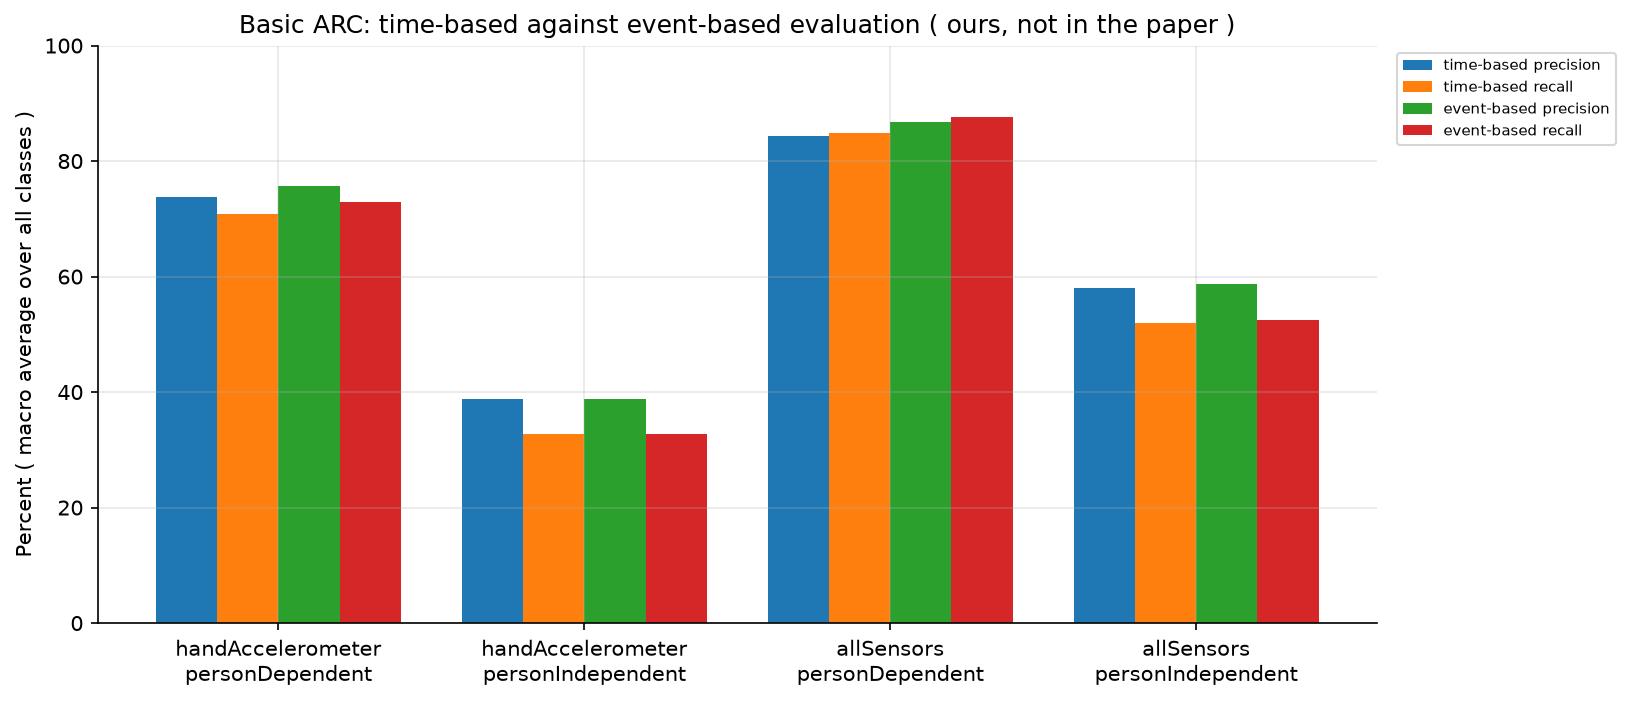

In [13]:
study.evaluateEvents(basicTable)
display(readCsv(study.resultsDirectory / "extraEventEvaluation.csv").head(10))
display(Image(filename=str(study.figuresDirectory / "extraEventEvaluation.png")))

### Extra b: Loss to NULL

Many gesture frames end up labelled NULL, the class for no gesture. This step measures, for each gesture, the share of its frames that the basic chain labels as NULL.

,sensorSet,scheme,classLabel,className,frames,recall,shareLostToNull,shareOfMissesToNull
0,handAccelerometer,personDependent,2,Open window,5371,0.627630,0.194563,0.522500
1,handAccelerometer,personDependent,3,Drink,7866,0.766718,0.090643,0.388556
2,handAccelerometer,personDependent,4,Water plant,8210,0.624848,0.146894,0.391558
3,handAccelerometer,personDependent,5,Close window,6354,0.591281,0.171545,0.419715
4,handAccelerometer,personDependent,6,Cut,9310,0.742642,0.100000,0.388564
5,handAccelerometer,personDependent,7,Chop,9040,0.728761,0.058407,0.215334
6,handAccelerometer,personDependent,8,Stir,9594,0.749218,0.120596,0.480881
7,handAccelerometer,personDependent,9,Book,12992,0.746305,0.121613,0.479369
8,handAccelerometer,personDependent,10,Forehand,4124,0.708050,0.133851,0.458472
9,handAccelerometer,personDependent,11,Backhand,3622,0.736057,0.125897,0.476987


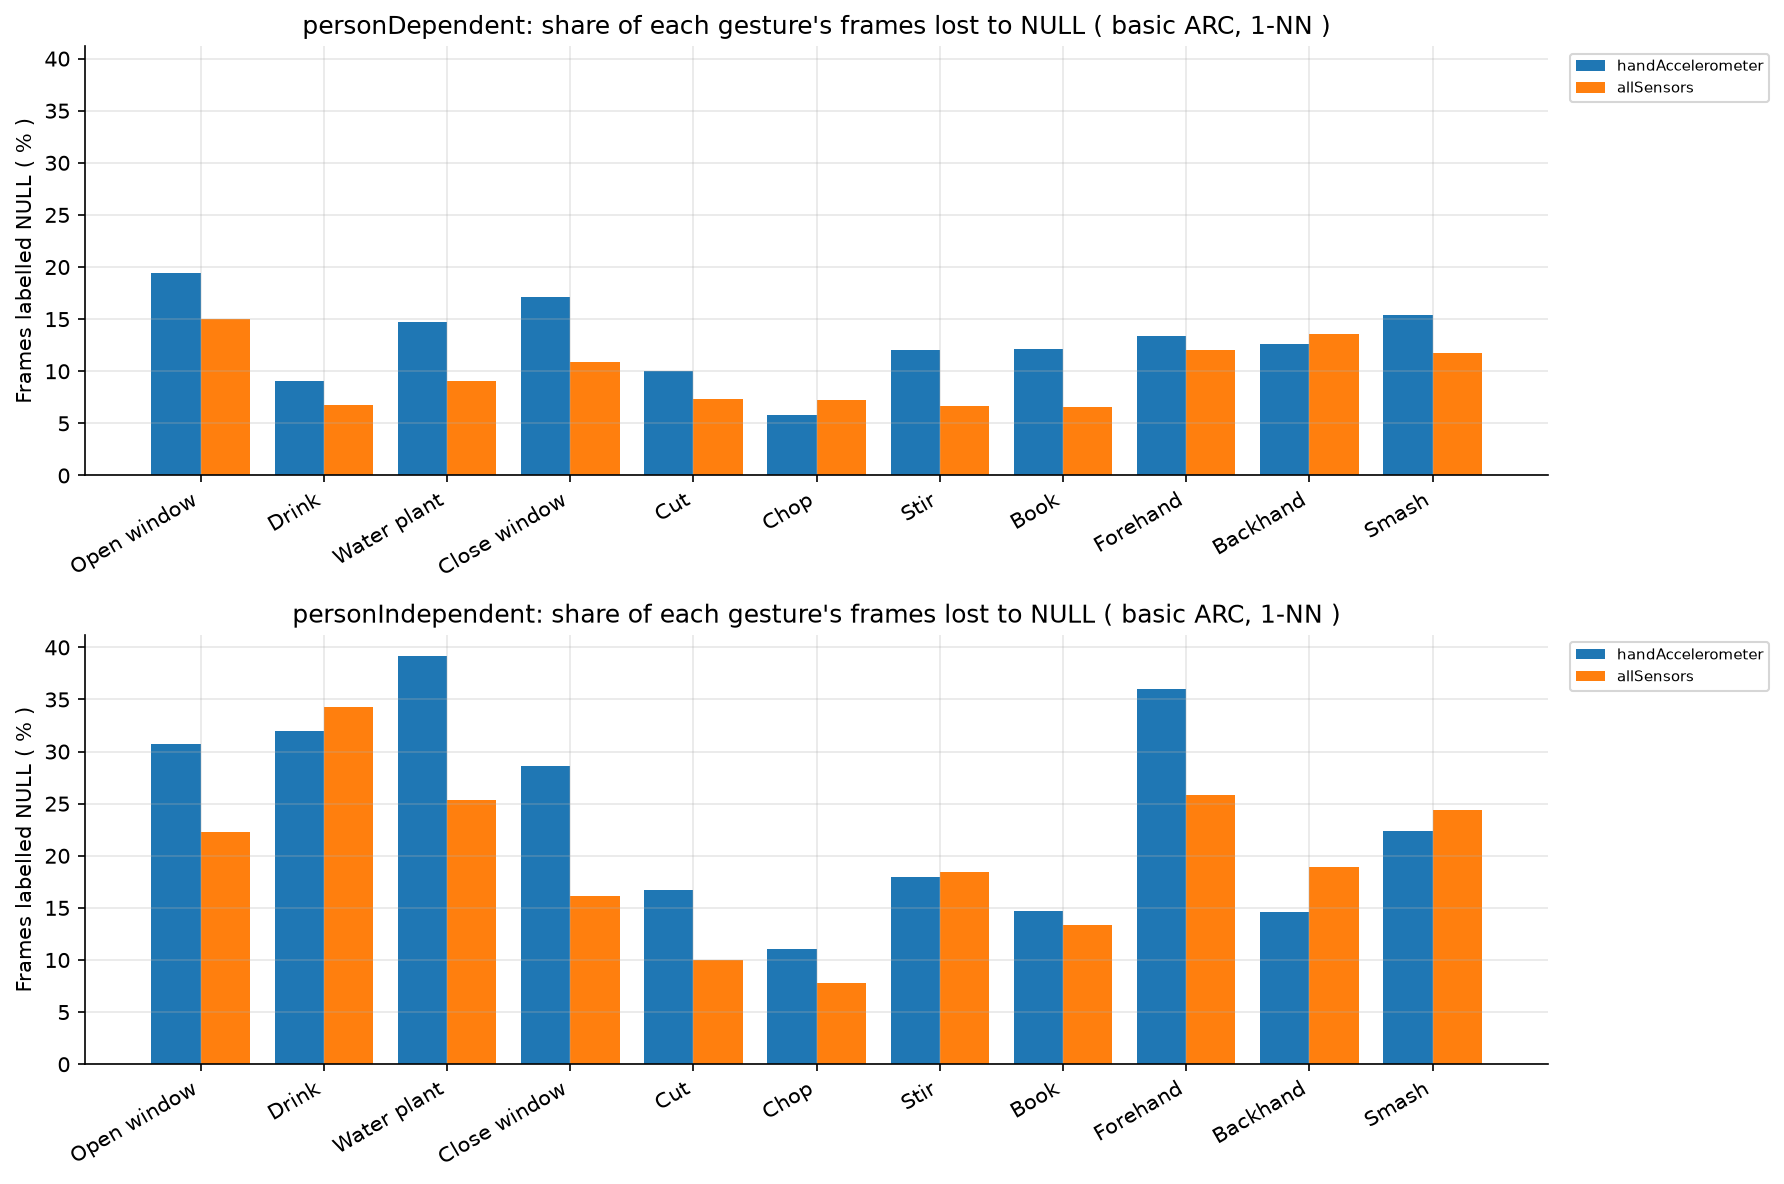

In [14]:
study.measureNullLoss()
display(readCsv(study.resultsDirectory / "extraNullLoss.csv").head(10))
display(Image(filename=str(study.figuresDirectory / "extraNullLoss.png")))

### Extra c: Filled frames replaced

This step reruns the hand accelerometer and every placement after replacing the filled frames without using labels. One replacement uses the mean of the sensor and the other draws a straight line between the neighbouring values. The change columns show how much the filled frames matter.

In [15]:
study.testFillSensitivity(basicTable, placementTable)
display(readCsv(study.resultsDirectory / "extraFillSensitivity.csv").head(10))

[ CHAIN : fillSensitivity mean handAccelerometer ] : done


[ CHAIN : fillSensitivity mean hand ] : done


[ CHAIN : fillSensitivity mean lowerArm ] : done


[ CHAIN : fillSensitivity mean upperArm ] : done


[ CHAIN : fillSensitivity mean handLowerArm ] : done


...

[ CHAIN : fillSensitivity interpolate handLowerArm ] : done


[ CHAIN : fillSensitivity interpolate handUpperArm ] : done


[ CHAIN : fillSensitivity interpolate lowerUpperArm ] : done


[ CHAIN : fillSensitivity interpolate allPlacements ] : done


,replacement,configuration,sensors,scheme,precisionAllPublished,precisionAllFillFree,precisionAllChange,recallAllPublished,recallAllFillFree,recallAllChange,precisionNonNullPublished,precisionNonNullFillFree,precisionNonNullChange,recallNonNullPublished,recallNonNullFillFree,recallNonNullChange
0,mean,handAccelerometer,acc_1,personDependent,0.738572,0.738057,-0.000515,0.708650,0.708490,-0.000160,0.740725,0.740178,-0.000546,0.705046,0.705046,0.000000
1,mean,handAccelerometer,acc_1,personIndependent,0.388413,0.388330,-0.000083,0.327113,0.326803,-0.000310,0.364124,0.364124,0.000000,0.296833,0.296833,0.000000
2,mean,hand,acc_1+gyr_1,personDependent,0.789544,0.789544,0.000000,0.783812,0.783812,0.000000,0.794741,0.794741,0.000000,0.788044,0.788044,0.000000
3,mean,hand,acc_1+gyr_1,personIndependent,0.433107,0.432358,-0.000749,0.382520,0.382166,-0.000355,0.413001,0.412295,-0.000706,0.350405,0.350405,0.000000
4,mean,lowerArm,acc_2+gyr_2,personDependent,0.775261,0.766655,-0.008606,0.760223,0.750562,-0.009661,0.780499,0.771745,-0.008754,0.763386,0.753252,-0.010134
5,mean,lowerArm,acc_2+gyr_2,personIndependent,0.444222,0.441708,-0.002515,0.413647,0.413795,0.000148,0.425613,0.422612,-0.003001,0.389402,0.389694,0.000292
6,mean,upperArm,acc_3+gyr_3,personDependent,0.775514,0.775751,0.000236,0.764095,0.764144,0.000049,0.781853,0.782115,0.000262,0.766654,0.766654,0.000000
7,mean,upperArm,acc_3+gyr_3,personIndependent,0.332966,0.332772,-0.000194,0.255489,0.255135,-0.000355,0.316724,0.316673,-0.000051,0.229627,0.229627,0.000000
8,mean,handLowerArm,acc_1+gyr_1+acc_2+gyr_2,personDependent,0.825887,0.825800,-0.000087,0.822838,0.820656,-0.002183,0.831667,0.831809,0.000142,0.829312,0.826916,-0.002396
9,mean,handLowerArm,acc_1+gyr_1+acc_2+gyr_2,personIndependent,0.546434,0.544317,-0.002118,0.488524,0.488272,-0.000251,0.534803,0.532478,-0.002325,0.465325,0.465708,0.000383


### Extra d: Zero line of the crossing rate

The crossing rate counts how often a channel crosses a zero line. The main runs take the mean of the whole recording as that line. This step reruns the person independent rounds with the mean of the training person instead.

In [16]:
study.testZeroLineSensitivity(featureTable, selectionTable)
display(readCsv(study.resultsDirectory / "extraZeroLineSensitivity.csv").head(10))

[ CHAIN : zeroLineSensitivity training subject 1 ] : done


[ CHAIN : zeroLineSensitivity training subject 2 ] : done


,configuration,selectedFeatures,scheme,rounds,precisionAllPublished,precisionAllTrainingZeroLine,precisionAllChange,recallAllPublished,recallAllTrainingZeroLine,recallAllChange,precisionNonNullPublished,precisionNonNullTrainingZeroLine,precisionNonNullChange,recallNonNullPublished,recallNonNullTrainingZeroLine,recallNonNullChange
0,handAccelerometer.Simple,NaN,personIndependent,2,0.382060,0.390357,0.008296,0.382114,0.382227,0.000112,0.354774,0.363279,0.008504,0.352034,0.349939,-0.002095
1,handAccelerometer.All,NaN,personIndependent,2,0.373269,0.369313,-0.003956,0.363596,0.356539,-0.007057,0.346857,0.343407,-0.003450,0.337060,0.329226,-0.007834
2,allSensors.Simple,NaN,personIndependent,2,0.549524,0.553000,0.003476,0.519929,0.508567,-0.011362,0.532192,0.536991,0.004798,0.501327,0.489541,-0.011786
3,allSensors.All,NaN,personIndependent,2,0.497294,0.501854,0.004560,0.467006,0.465822,-0.001185,0.477469,0.483516,0.006047,0.447542,0.446758,-0.000784
4,allSensors.All.mRMR,1.0,personIndependent,2,0.169383,0.169383,0.000000,0.163766,0.163766,0.000000,0.135616,0.135616,0.000000,0.135013,0.135013,0.000000
5,allSensors.All.mRMR,5.0,personIndependent,2,0.360661,0.366616,0.005954,0.307469,0.314679,0.007210,0.339739,0.345576,0.005837,0.268464,0.274816,0.006351
6,allSensors.All.mRMR,10.0,personIndependent,2,0.414965,0.427276,0.012311,0.342557,0.343938,0.001381,0.395948,0.410999,0.015051,0.304045,0.304739,0.000694
7,allSensors.All.mRMR,20.0,personIndependent,2,0.543500,0.546261,0.002762,0.490100,0.457140,-0.032960,0.527345,0.533329,0.005984,0.467640,0.430751,-0.036889
8,allSensors.All.mRMR,25.0,personIndependent,2,0.574131,0.582084,0.007953,0.502202,0.491769,-0.010433,0.560222,0.571306,0.011084,0.481266,0.469806,-0.011459
9,allSensors.All.mRMR,50.0,personIndependent,2,0.581595,0.605648,0.024052,0.536002,0.528120,-0.007883,0.568292,0.595221,0.026929,0.520995,0.510699,-0.010296


### Confusion matrices of the basic chain

This step pools the rounds of both people and shows which classes the basic chain mixes up. Each row is a true class. The cells show where the frames of that class went.

,sensorSet,scheme,trueClass,predictedClass,frames
0,handAccelerometer,personDependent,NULL,NULL,39078
1,handAccelerometer,personDependent,NULL,Open window,1228
2,handAccelerometer,personDependent,NULL,Drink,1620
3,handAccelerometer,personDependent,NULL,Water plant,1397
4,handAccelerometer,personDependent,NULL,Close window,2153
5,handAccelerometer,personDependent,NULL,Cut,986
6,handAccelerometer,personDependent,NULL,Chop,1263
7,handAccelerometer,personDependent,NULL,Stir,1336
8,handAccelerometer,personDependent,NULL,Book,2081
9,handAccelerometer,personDependent,NULL,Forehand,882


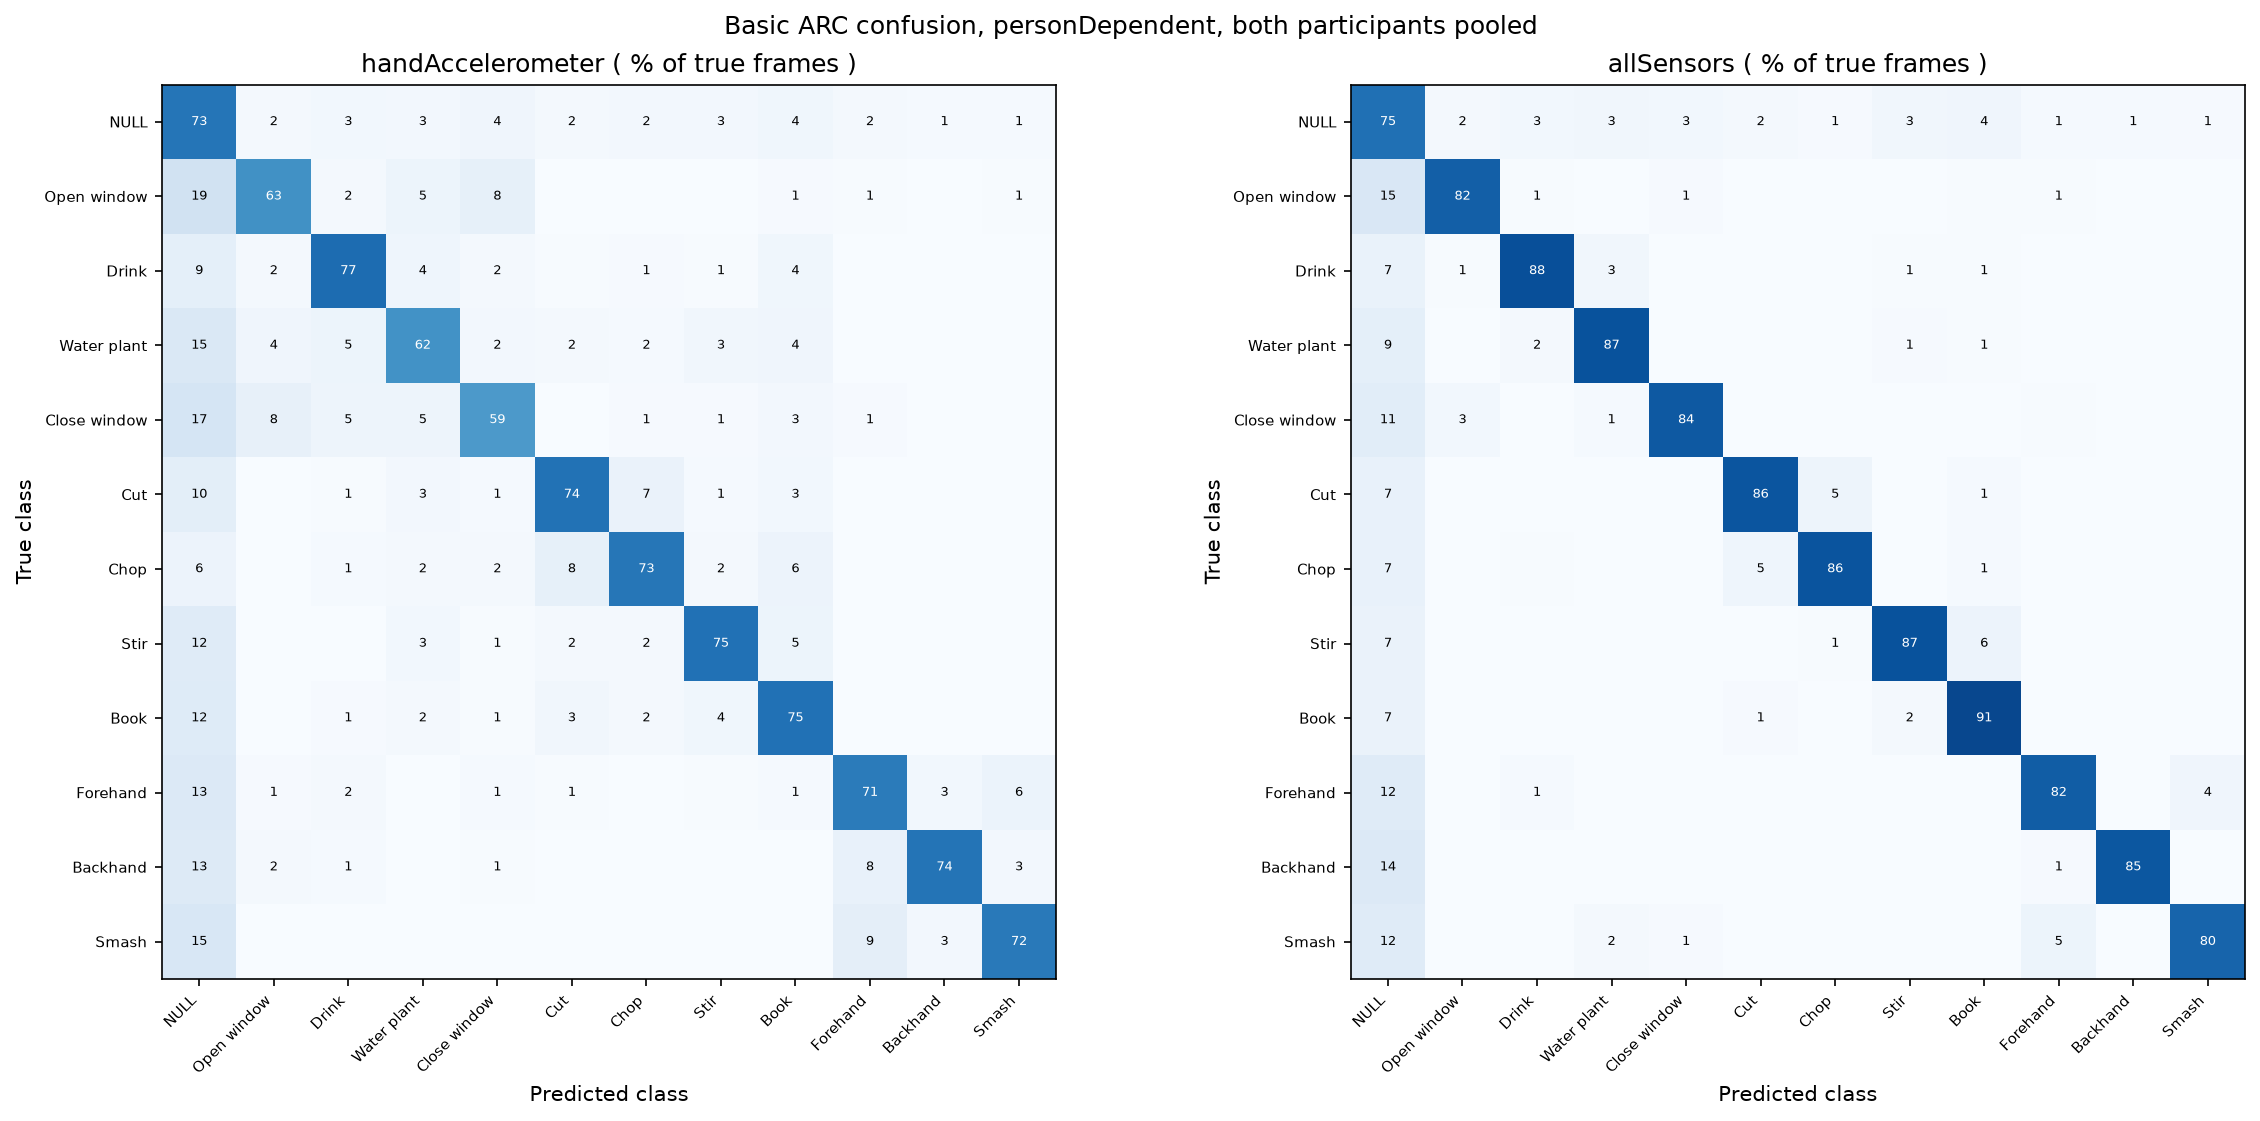

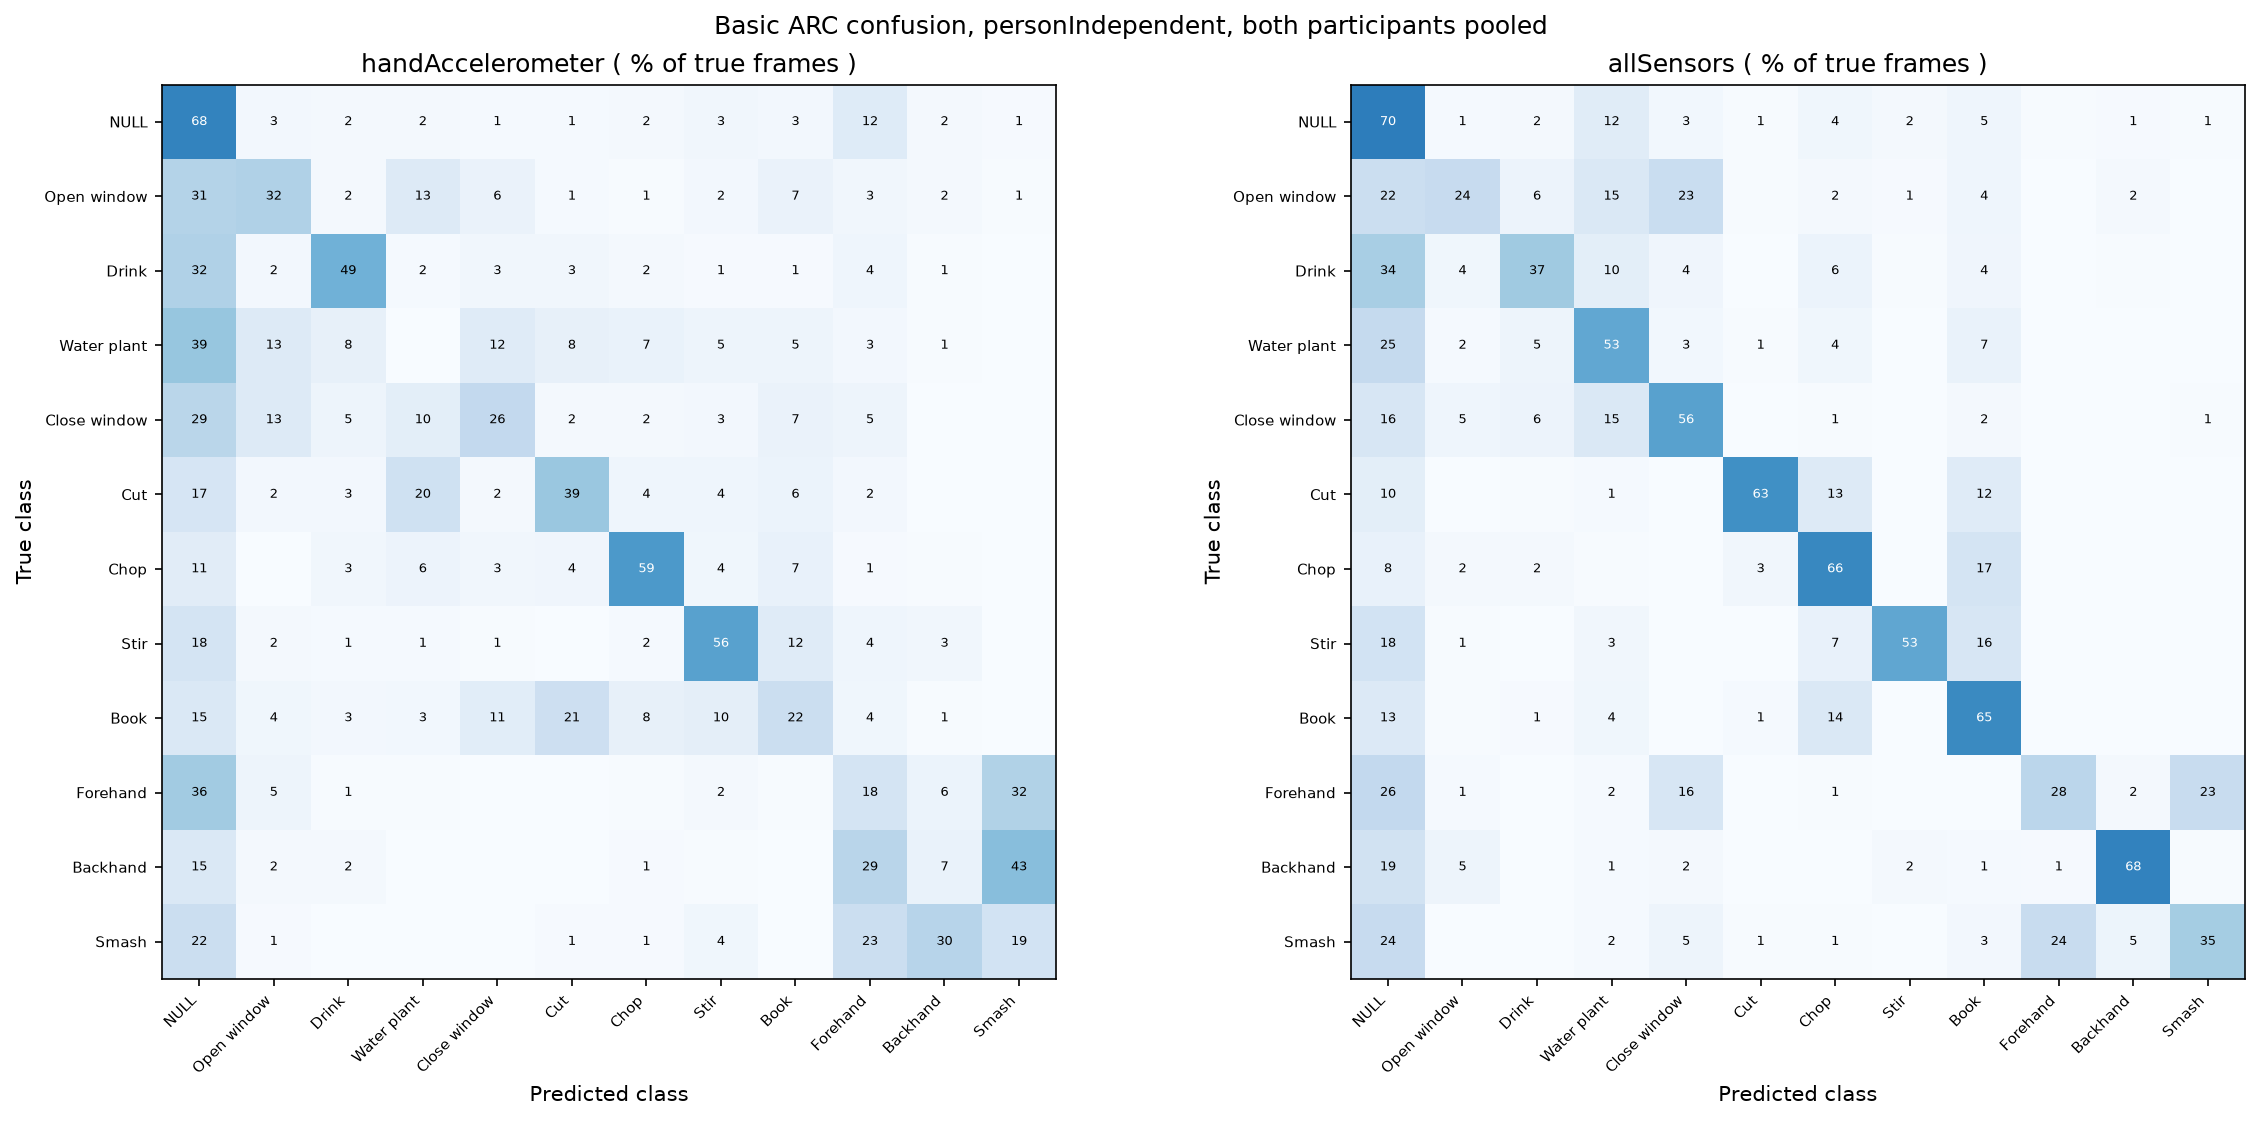

In [17]:
study.plotConfusions()
display(readCsv(study.resultsDirectory / "basicChainConfusion.csv").head(10))
display(Image(filename=str(study.figuresDirectory / "confusionBasicPersonDependent.png")))
display(Image(filename=str(study.figuresDirectory / "confusionBasicPersonIndependent.png")))

## Part 4: Comparison with the paper

### The values the paper prints

This step writes the precision and recall values that the paper prints, with the page and the sentence that holds each one. It also writes the statements of the paper, which a later step tests.

In [18]:
referenceTable = study.buildPaperReference()
display(readCsv(study.resultsDirectory / "paperReference.csv").head(10))

,referenceId,referenceType,section,page,scheme,configuration,classifier,selectedFeatures,paperPrecision,paperRecall,paperSentence,source
0,5.1-pd-handAccelerometer,value,5.1,33:20,personDependent,handAccelerometer,kNearestNeighbour,NaN,76.2,44.2,training and testing on the same person result...,printed in the paper text (ulfblanke.de/resear...
1,5.1-pd-allSensors,value,5.1,33:20,personDependent,allSensors,kNearestNeighbour,NaN,94.1,62.4,"When using all sensors, precision increases to...",printed in the paper text (ulfblanke.de/resear...
2,5.1-pi-handAccelerometer,value,5.1,33:20,personIndependent,handAccelerometer,kNearestNeighbour,NaN,44.7,21.4,"For the person-independent case, results are l...",printed in the paper text (ulfblanke.de/resear...
3,5.1-pi-allSensors,value,5.1,33:20,personIndependent,allSensors,kNearestNeighbour,NaN,63.0,39.5,Using data from all sensors attached to three ...,printed in the paper text (ulfblanke.de/resear...
4,5.4-pd-hand,value,5.4,33:22,personDependent,hand,kNearestNeighbour,NaN,87.2,55.1,The best result for individual placement is ob...,printed in the paper text (ulfblanke.de/resear...
5,5.4-pi-upperArm,value,5.4,33:22,personIndependent,upperArm,kNearestNeighbour,NaN,30.2,11.4,The worst performance is obtained at the upper...,printed in the paper text (ulfblanke.de/resear...
6,5.5-pd-accAll,value,5.5,33:23,personDependent,accAll,kNearestNeighbour,NaN,90.4,58.6,The best results for the person-dependent case...,printed in the paper text (ulfblanke.de/resear...
7,5.5-pd-bestGyroscope,value,5.5,33:23,personDependent,bestGyroscopeOnly,kNearestNeighbour,NaN,85.2,46.4,"Using gyroscopes only, the best performance is...",printed in the paper text (ulfblanke.de/resear...
8,5.6-pd-svm,value,5.6,33:24,personDependent,allSensors,supportVectorMachine,NaN,96.0,84.8,the best results for all available data are ac...,printed in the paper text (ulfblanke.de/resear...
9,5.6-pd-naiveBayes,value,5.6,33:24,personDependent,allSensors,gaussianNaiveBayes,NaN,78.2,69.2,The worst performance is exhibited by naive Ba...,printed in the paper text (ulfblanke.de/resear...


### Our values next to the paper's

This step pairs every printed value with our value for the same setup. It measures the gap under several ways of averaging over the classes and at both window steps. The figure shows our values next to the printed ones.

,referenceId,comparedAs,comparedClassifier,section,page,scheme,paperConfiguration,ourConfiguration,stepVariant,paperPrecision,...,ourRecall_nonNull11DefinedPrecision,precisionDifference_nonNull11DefinedPrecision,recallDifference_nonNull11DefinedPrecision,absoluteGap_nonNull11DefinedPrecision,bestGapAllClasses,bestGapGestureClasses,closerClassSet,classSetMargin,precisionConvention,duplicateOf
0,5.1-pd-handAccelerometer,main,kNearestNeighbour,5.1,33:20,personDependent,handAccelerometer,handAccelerometer.kNearestNeighbour.paperStep,paperStep,76.2,...,70.504605,-1.997040,26.304605,28.301645,28.890210,28.301645,gesture classes,0.588565,defined precision closer,NaN
1,5.1-pd-handAccelerometer,main,kNearestNeighbour,5.1,33:20,personDependent,handAccelerometer,handAccelerometer.kNearestNeighbour.toolboxStep,toolboxStep,76.2,...,76.883325,0.094571,32.683325,32.777896,32.740806,32.777896,all classes,0.037089,"same, no class went unpredicted",NaN
2,5.1-pd-handAccelerometer,secondRow,nearestClassCentroid,5.1,33:20,personDependent,handAccelerometer,handAccelerometer.nearestClassCentroid.paperStep,paperStep,76.2,...,54.239266,-7.839984,10.039266,17.879250,20.204710,17.879250,gesture classes,2.325459,defined precision closer,NaN
3,5.1-pd-handAccelerometer,secondRow,nearestClassCentroid,5.1,33:20,personDependent,handAccelerometer,handAccelerometer.nearestClassCentroid.toolbox...,toolboxStep,76.2,...,54.915431,-8.669121,10.715431,19.384552,21.613657,19.384552,gesture classes,2.229106,"same, no class went unpredicted",NaN
4,5.1-pd-handAccelerometer,sensitivityRow,toolboxNearestNeighbours,5.1,33:20,personDependent,handAccelerometer,handAccelerometer.toolboxNearestNeighbours.pap...,paperStep,76.2,...,70.056835,2.915456,25.856835,28.772290,28.455175,28.001504,gesture classes,0.453672,zero precision closer,NaN
5,5.1-pd-allSensors,main,kNearestNeighbour,5.1,33:20,personDependent,allSensors,allSensors.kNearestNeighbour.paperStep,paperStep,94.1,...,85.620331,-9.028269,23.220331,32.248600,32.060939,32.248600,all classes,0.187661,defined precision closer,NaN
6,5.1-pd-allSensors,main,kNearestNeighbour,5.1,33:20,personDependent,allSensors,allSensors.kNearestNeighbour.toolboxStep,toolboxStep,94.1,...,90.712723,-6.052775,28.312723,34.365499,33.967683,34.365499,all classes,0.397816,"same, no class went unpredicted",NaN
7,5.1-pd-allSensors,secondRow,nearestClassCentroid,5.1,33:20,personDependent,allSensors,allSensors.nearestClassCentroid.paperStep,paperStep,94.1,...,59.355423,-16.857824,-3.044577,19.902401,18.850414,19.902401,all classes,1.051987,defined precision closer,NaN
8,5.1-pd-allSensors,secondRow,nearestClassCentroid,5.1,33:20,personDependent,allSensors,allSensors.nearestClassCentroid.toolboxStep,toolboxStep,94.1,...,61.190042,-16.870700,-1.209958,18.080658,18.491215,18.080658,gesture classes,0.410556,"same, no class went unpredicted",NaN
9,5.1-pd-allSensors,sensitivityRow,toolboxNearestNeighbours,5.1,33:20,personDependent,allSensors,allSensors.toolboxNearestNeighbours.paperStep,paperStep,94.1,...,84.396652,-5.989282,21.996652,27.985934,28.932775,27.985934,gesture classes,0.946842,defined precision closer,NaN


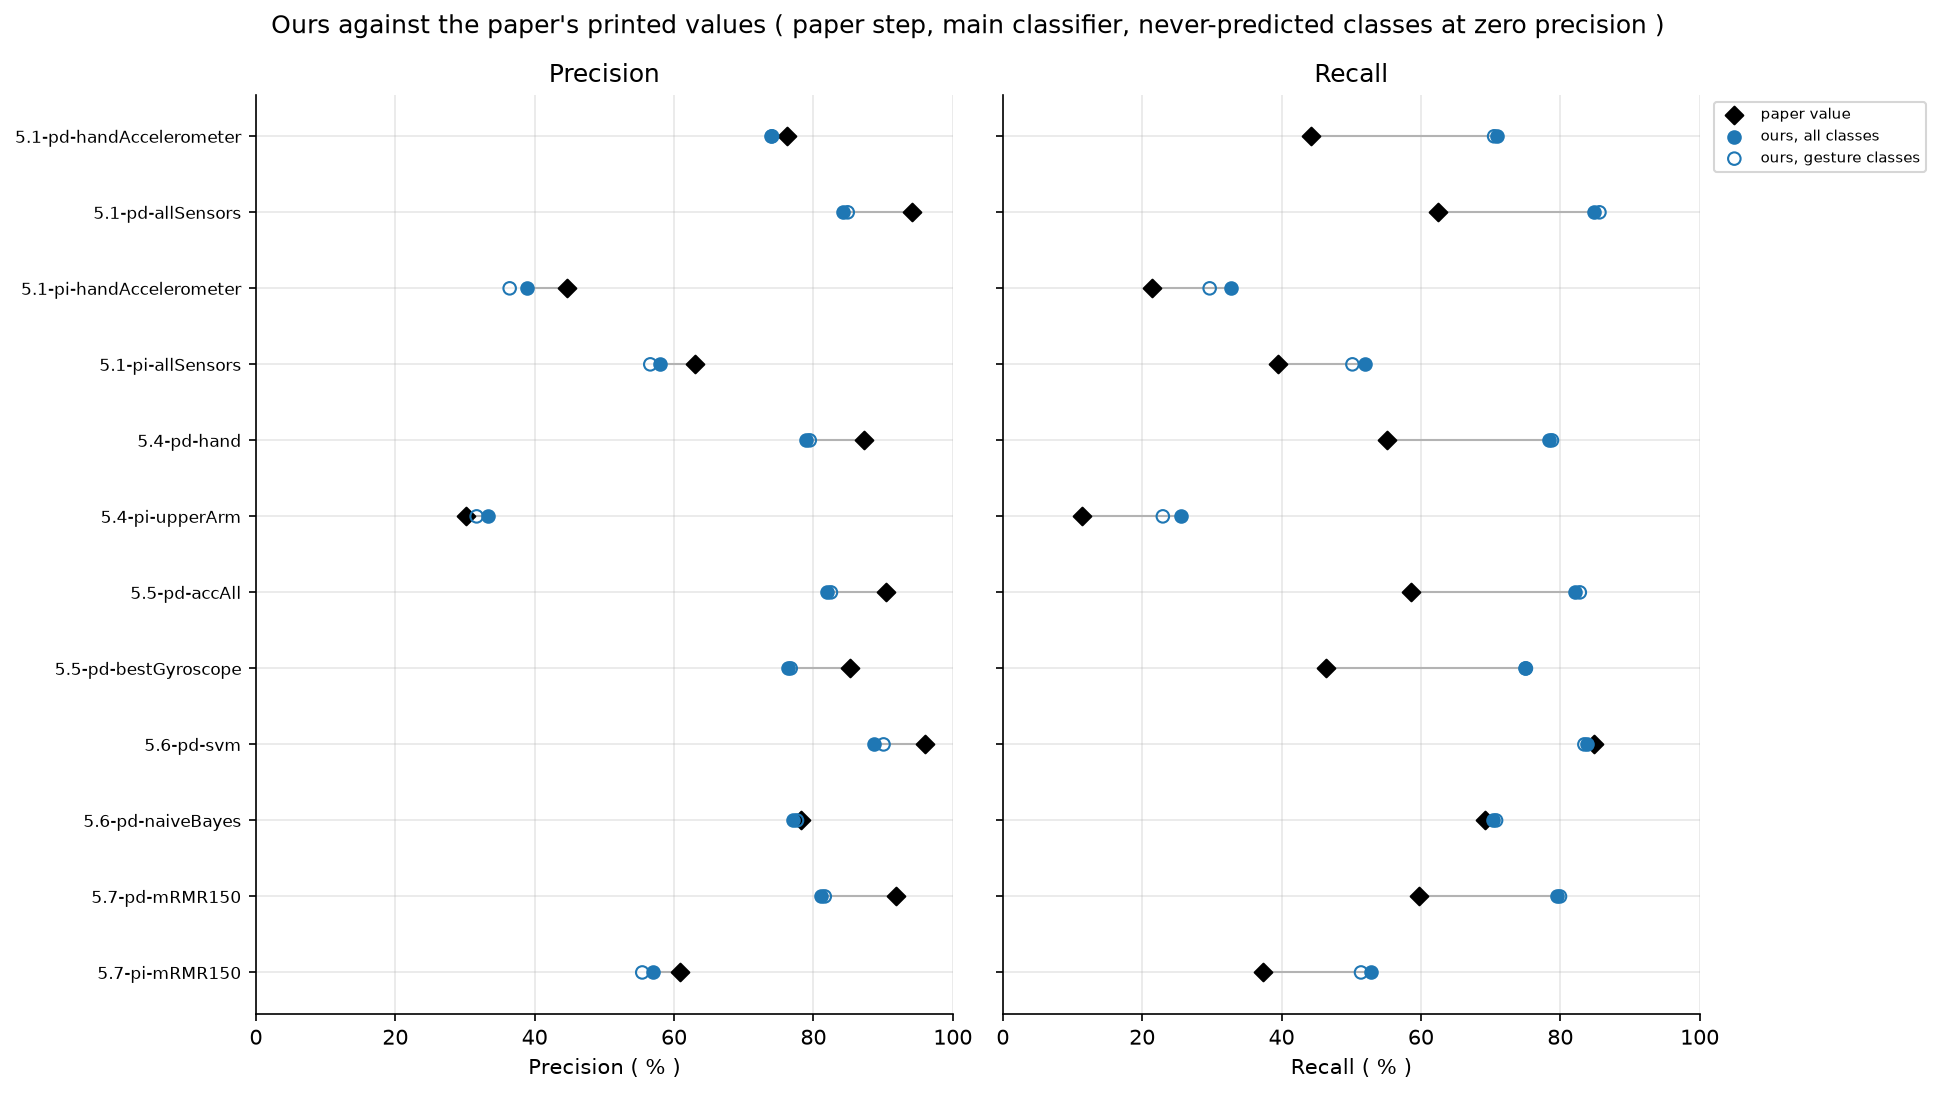

In [19]:
sectionTables = {
    "5.1": basicTable, "5.2": featureTable, "5.3": windowTable, "5.4": placementTable,
    "5.5": modalityTable, "5.6": classifierTable, "5.7": selectionTable,
}
study.comparePaper(referenceTable, sectionTables)
display(readCsv(study.resultsDirectory / "paperComparison.csv").head(10))
display(Image(filename=str(study.figuresDirectory / "paperComparison.png")))

### The statements of the paper

This step tests the statements of the paper against our results, for example that a certain window size gives the best precision. Each row says whether a statement holds for one case.

In [20]:
study.checkQualitativeClaims(featureTable, windowTable, classifierTable, selectionTable, referenceTable)
display(readCsv(study.resultsDirectory / "qualitativeChecks.csv").head(10))

,referenceId,section,page,scheme,variant,paperStatement,ourFinding,precisionChange,recallChange,firstPartHolds,secondPartHolds,holds
0,5.3-statement,5.3,33:22,personDependent,paperStep,We can see that precision reaches a maximum Ws...,"precision peaks at Ws = 2 s, 1.25 points above...",NaN,NaN,False,False,False
1,5.3-statement,5.3,33:22,personIndependent,paperStep,We can see that precision reaches a maximum Ws...,"precision peaks at Ws = 4 s, 0.01 points above...",NaN,NaN,False,False,False
2,5.3-statement,5.3,33:22,personDependent,toolboxStep,We can see that precision reaches a maximum Ws...,"precision peaks at Ws = 1 s, 1.33 points above...",NaN,NaN,True,False,False
3,5.3-statement,5.3,33:22,personIndependent,toolboxStep,We can see that precision reaches a maximum Ws...,"precision peaks at Ws = 3 s, 0.54 points above...",NaN,NaN,False,False,False
4,5.2-statement,5.2,33:21,personDependent,handAccelerometer,The best performance is achieved by using mean...,best precision among the paper's feature types...,-13.478215,-13.608485,True,True,True
5,5.2-rawStatement,5.2,33:22,personDependent,handAccelerometer,"Using the raw signal (i.e., each frame instead...",Raw per frame minus VerySimple: recall -36.0 p...,-38.384199,-36.016726,False,True,False
6,5.2-statement,5.2,33:21,personIndependent,handAccelerometer,The best performance is achieved by using mean...,best precision among the paper's feature types...,-1.514418,3.648268,True,True,True
7,5.2-rawStatement,5.2,33:22,personIndependent,handAccelerometer,"Using the raw signal (i.e., each frame instead...",Raw per frame minus VerySimple: recall -12.5 p...,-18.101211,-12.515110,False,True,False
8,5.2-statement,5.2,33:21,personDependent,allSensors,The best performance is achieved by using mean...,best precision among the paper's feature types...,-10.182067,-12.717696,True,True,True
9,5.2-rawStatement,5.2,33:22,personDependent,allSensors,"Using the raw signal (i.e., each frame instead...",Raw per frame minus VerySimple: recall -8.3 po...,-8.805614,-8.273218,False,True,False


## Part 5: Figures, round metrics and run parameters

### Figures of the sections

This step draws one figure for each section of Part 2, with the printed paper values marked where there are any.

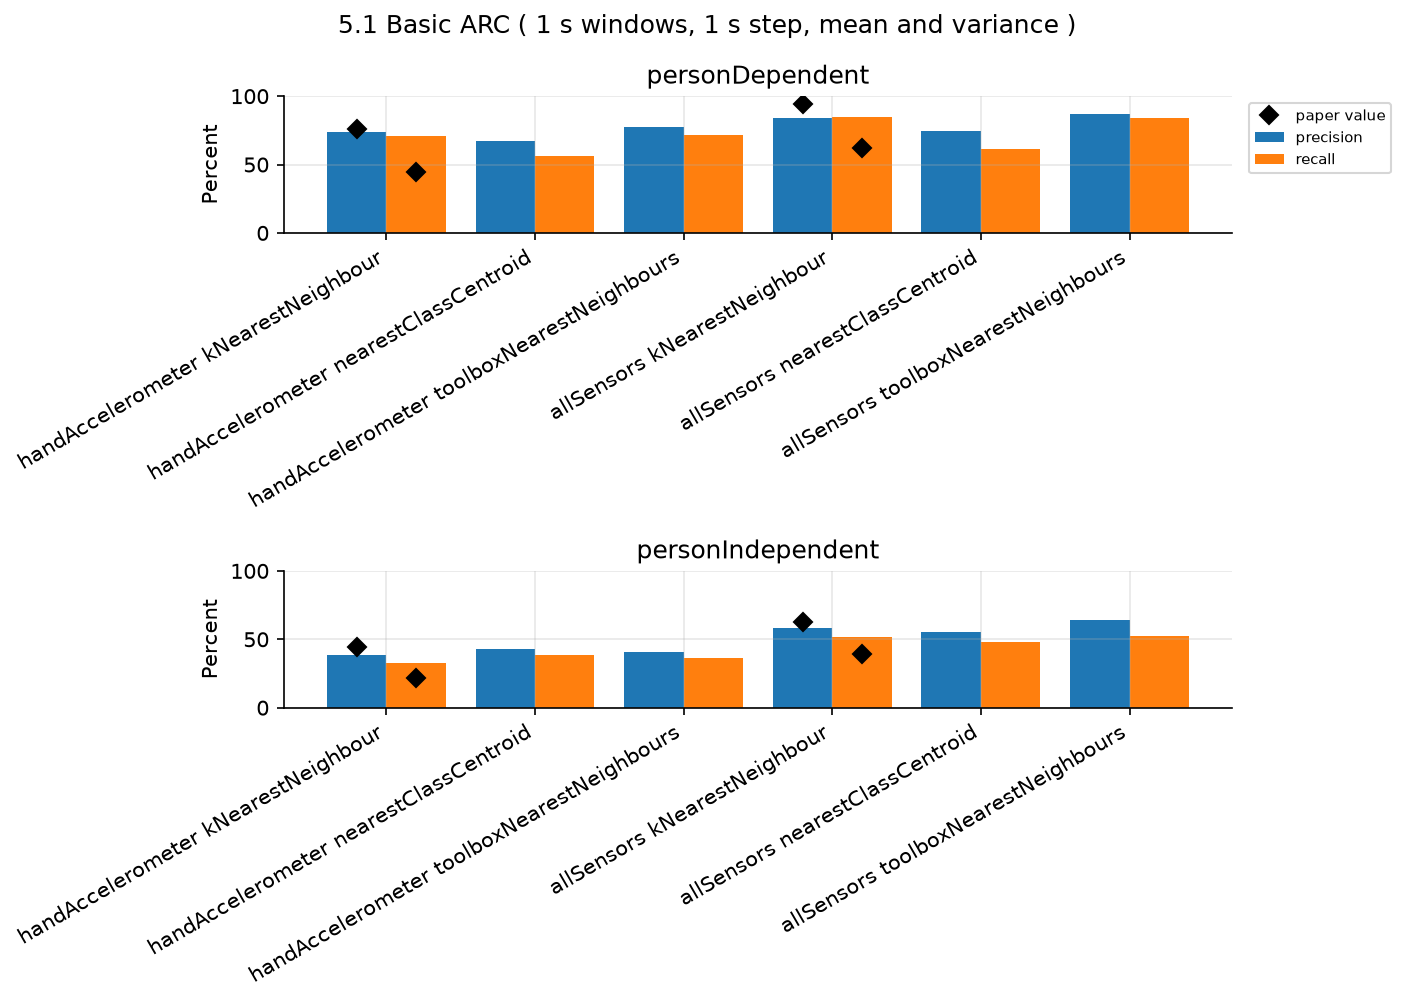

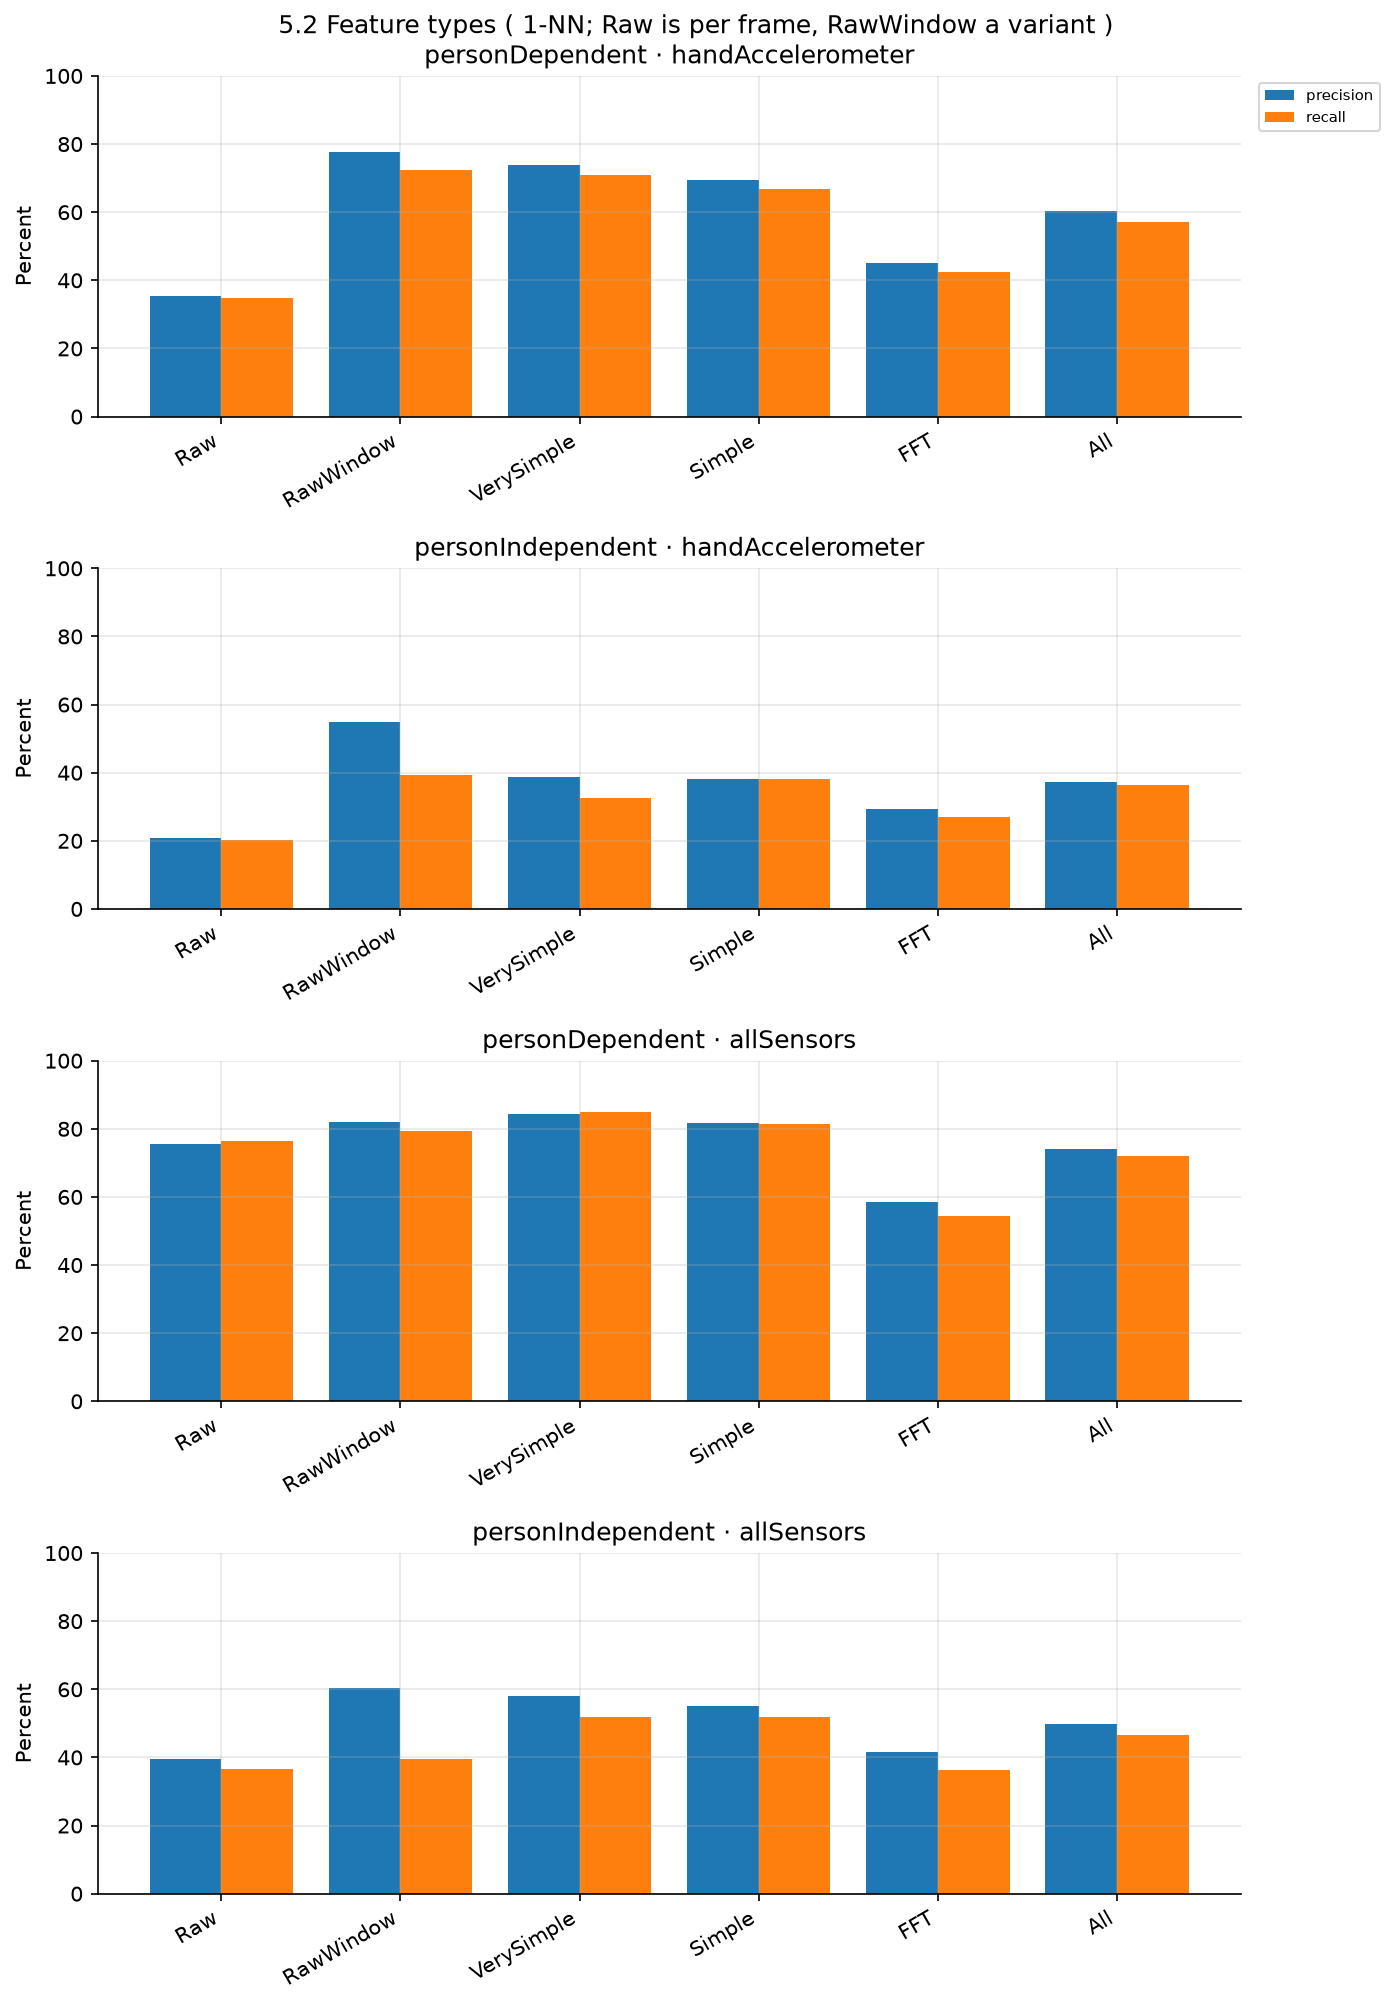

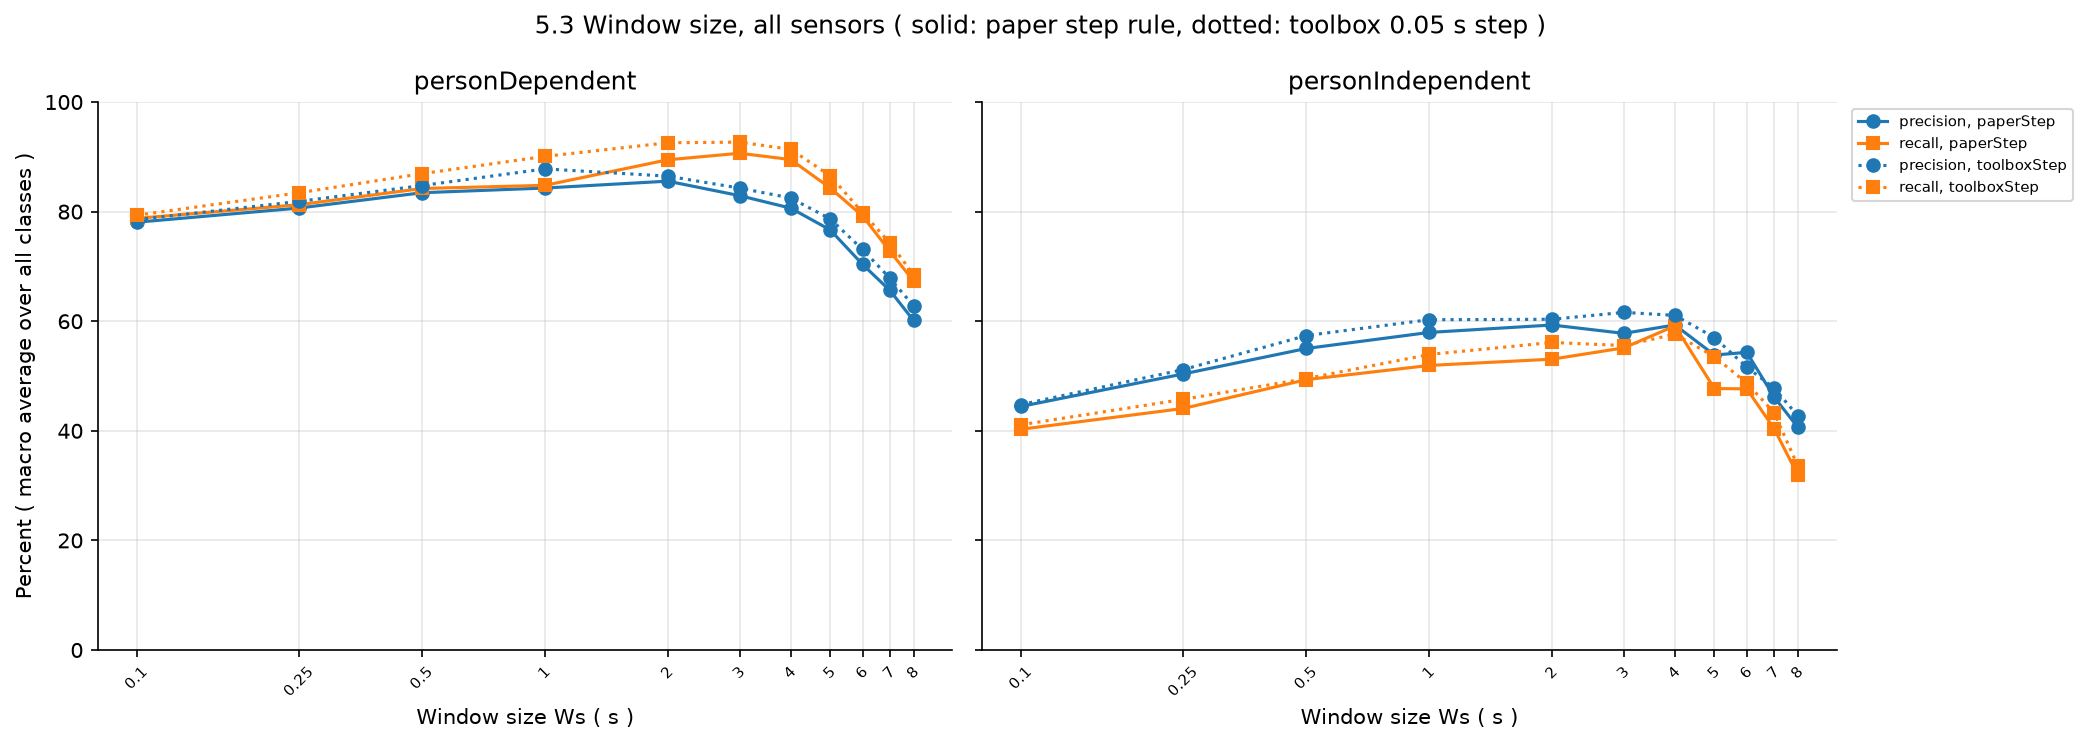

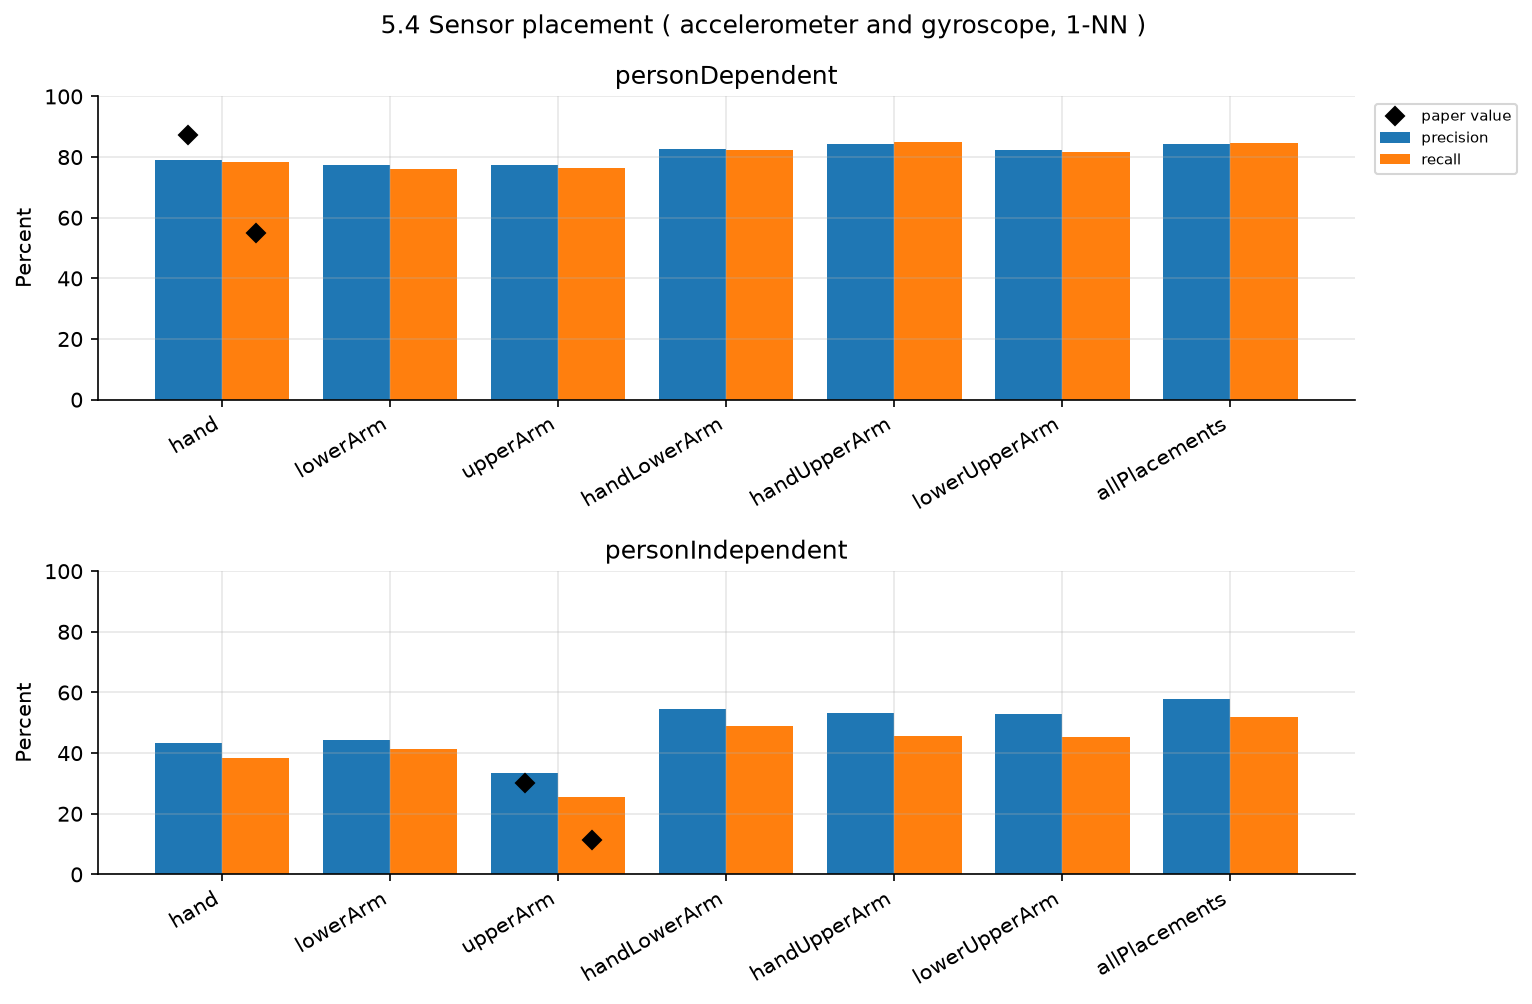

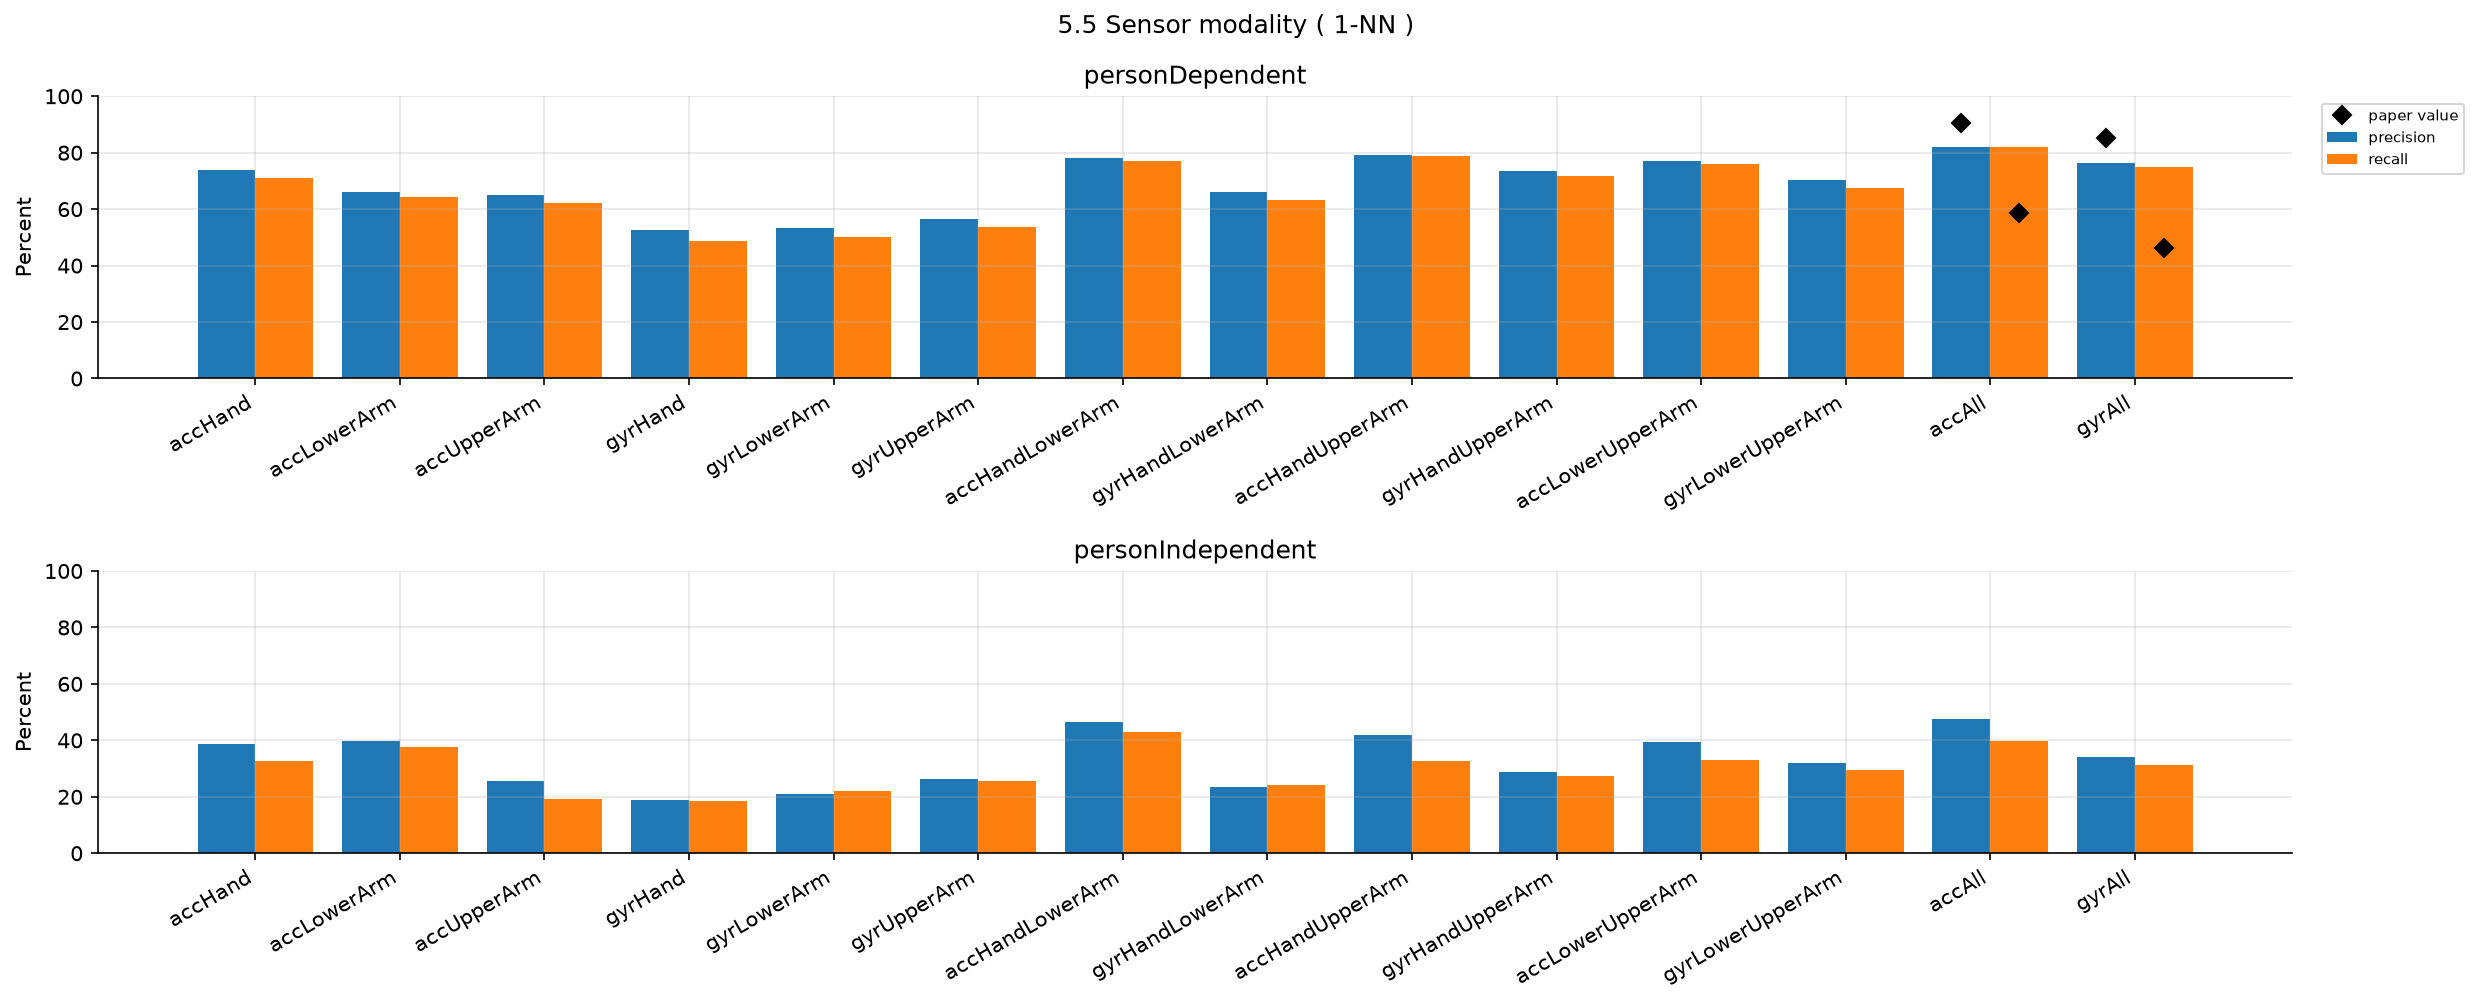

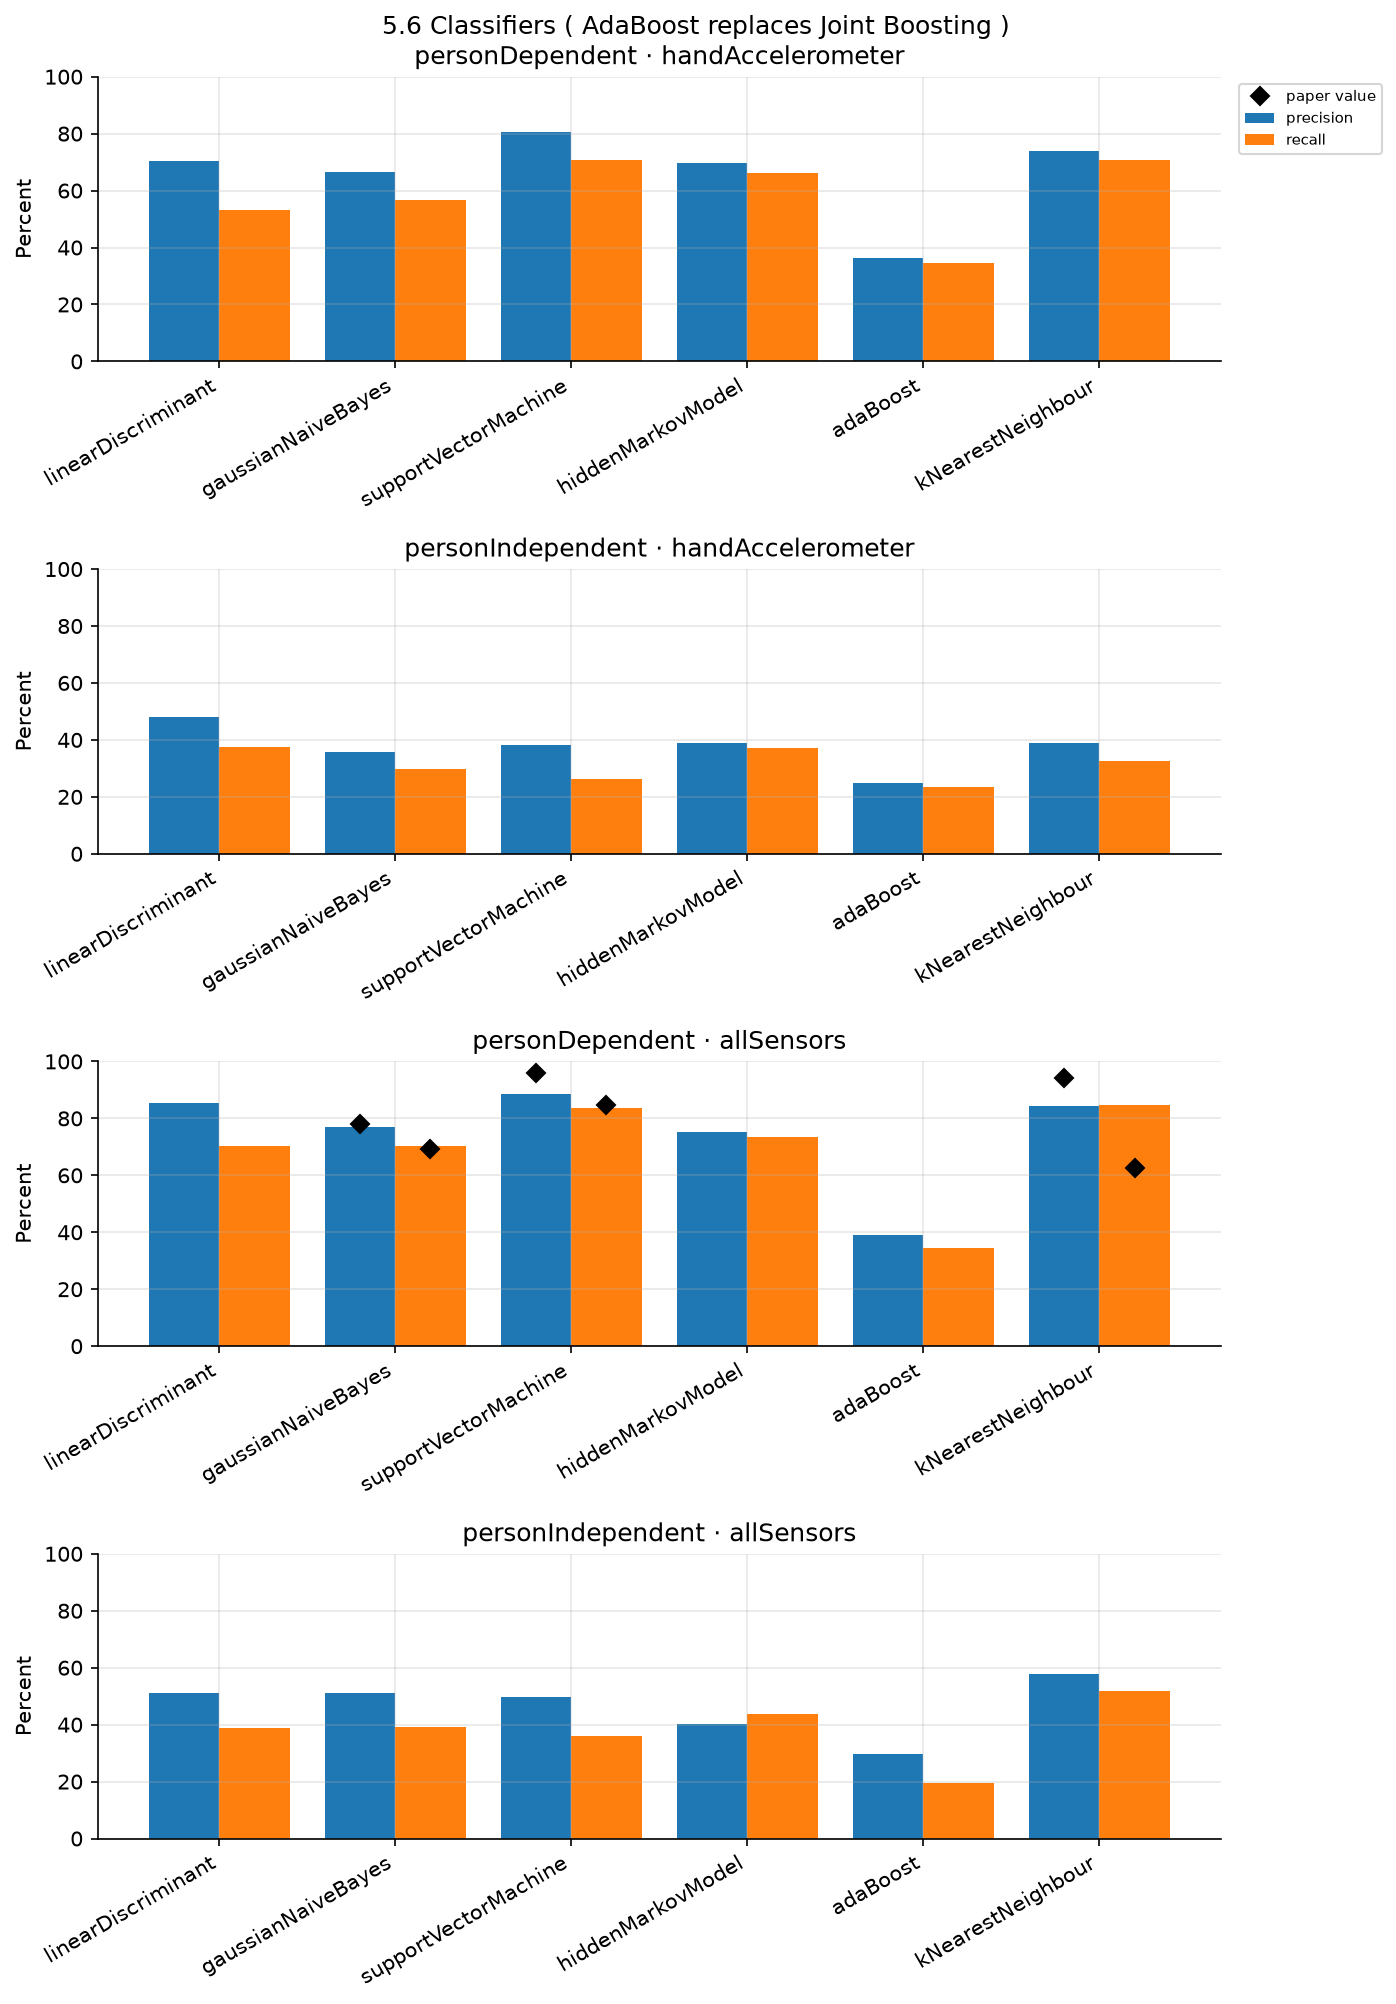

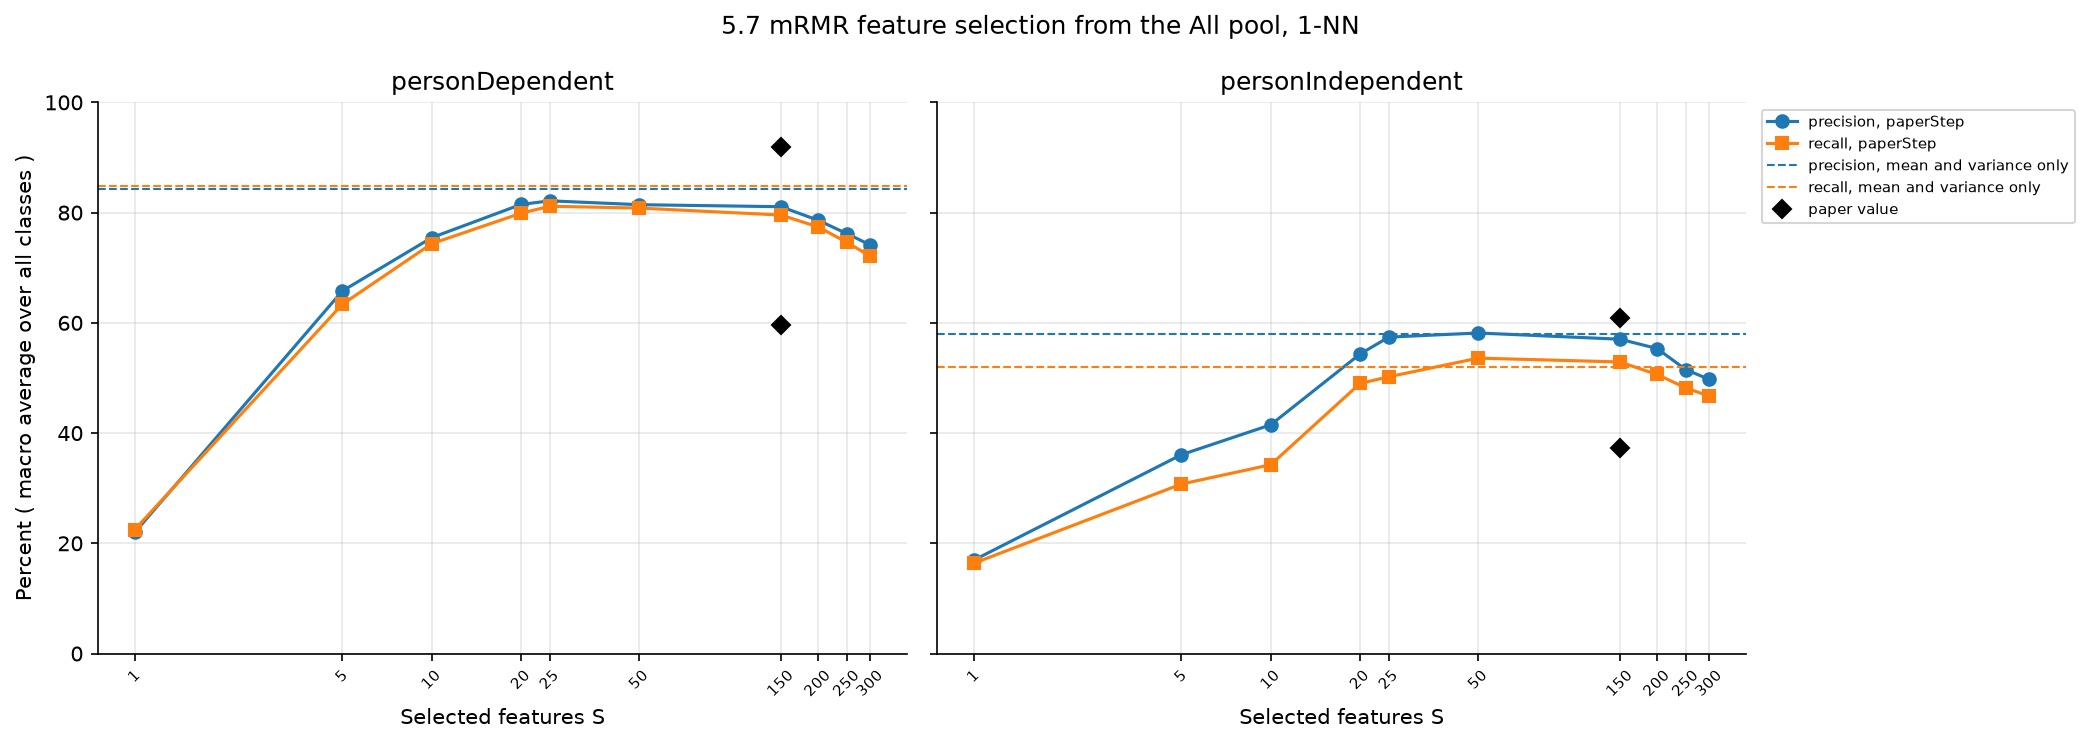

In [21]:
study.plotSections(sectionTables, referenceTable)
display(Image(filename=str(study.figuresDirectory / "section51BasicChain.png")))
display(Image(filename=str(study.figuresDirectory / "section52FeatureTypes.png")))
display(Image(filename=str(study.figuresDirectory / "section53WindowSizes.png")))
display(Image(filename=str(study.figuresDirectory / "section54Placements.png")))
display(Image(filename=str(study.figuresDirectory / "section55Modalities.png")))
display(Image(filename=str(study.figuresDirectory / "section56Classifiers.png")))
display(Image(filename=str(study.figuresDirectory / "section57FeatureSelection.png")))

### Round metrics

Every cross validation round of the main sections has its own scores. This step writes all of them to one table.

In [22]:
study.writeRoundMetrics()
display(readCsv(study.resultsDirectory / "roundMetrics.csv").head(10))

,section,configuration,sensors,featureType,classifier,windowSeconds,stepSeconds,scheme,variant,round,...,eventRecallNonNull,eventPrecisionAllDefined,eventPrecisionNonNullDefined,eventClassesNeverPredicted,eventClassesAbsent,gestureSegments,detectedGestureSegments,constantFeatures,svmCost,svmGamma
0,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,1,...,0.606710,0.724954,0.709740,0,0,11,11,0.0,NaN,NaN
1,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,2,...,0.688528,0.753125,0.759091,0,0,11,11,0.0,NaN,NaN
2,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,3,...,0.568182,0.710228,0.699928,0,0,11,11,0.0,NaN,NaN
3,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,4,...,0.802814,0.839583,0.838636,0,0,11,11,0.0,NaN,NaN
4,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,5,...,0.674675,0.756854,0.755411,0,0,11,11,0.0,NaN,NaN
5,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,6,...,0.752092,0.780848,0.784848,0,0,11,11,0.0,NaN,NaN
6,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,7,...,0.728139,0.727877,0.735606,0,0,11,11,0.0,NaN,NaN
7,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,8,...,0.766667,0.785119,0.791558,0,0,11,11,0.0,NaN,NaN
8,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,9,...,0.625541,0.633920,0.616450,0,0,11,11,0.0,NaN,NaN
9,5.1,handAccelerometer.kNearestNeighbour.paperStep,acc_1,VerySimple,kNearestNeighbour,1.0,1.0,personDependent,NaN,10,...,0.759091,0.775050,0.771645,0,0,11,11,0.0,NaN,NaN


### Run parameters

This step writes every setting of the run and every check value, together with the library versions.

In [23]:
study.writeParameters()
display(readCsv(study.resultsDirectory / "runParameters.csv").head(10))

,section,parameter,value
0,run,randomSeed,42
1,run,nJobs,4
2,run,python,3.12.14
3,run,numpy,2.5.3
4,run,pandas,3.0.6
5,run,scipy,1.18.1
6,run,scikit-learn,1.9.1
7,run,hmmlearn,0.3.3
8,run,matplotlib,3.11.2
9,protocol,windowSeconds,1.0
